In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("results/reports/results.csv")

In [4]:
df.head()

,Model,Test_Accuracy,Best_Val_Accuracy,Best_Val_f1,Best_Val_Loss,Precision,Recall,F1,Epochs,prep_windowing,prep_clahe,prep_hist_eq,prep_gaussian,prep_median,prep_sharpen_flag,prep_norm_type
0,resnet50_vgg16_inceptionv3_baseline_ep30,0.981043,0.976378,0.949691,0.129168,0.981935,0.981043,0.980218,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,resnet50_vgg16_inceptionv3_windowing_ep30,0.962085,0.968504,0.951116,0.102105,0.961908,0.962085,0.961880,30,True,NaN,NaN,NaN,NaN,NaN,NaN
2,resnet50_vgg16_inceptionv3_clahe_ep30,0.938389,0.976378,0.949691,0.103920,0.962660,0.938389,0.943257,30,NaN,True,NaN,NaN,NaN,NaN,NaN
3,resnet50_vgg16_inceptionv3_hist_eq_ep30,0.947867,0.992126,0.982140,0.077242,0.946536,0.947867,0.944937,30,NaN,NaN,True,NaN,NaN,NaN,NaN
4,resnet50_vgg16_inceptionv3_window_clahe_ep30,0.895735,0.984252,0.963030,0.089145,0.950350,0.895735,0.906041,30,True,True,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Model              112 non-null    object 
 1   Test_Accuracy      112 non-null    float64
 2   Best_Val_Accuracy  112 non-null    float64
 3   Best_Val_f1        112 non-null    float64
 4   Best_Val_Loss      112 non-null    float64
 5   Precision          112 non-null    float64
 6   Recall             112 non-null    float64
 7   F1                 112 non-null    float64
 8   Epochs             112 non-null    int64  
 9   prep_windowing     42 non-null     object 
 10  prep_clahe         63 non-null     object 
 11  prep_hist_eq       7 non-null      object 
 12  prep_gaussian      14 non-null     object 
 13  prep_median        28 non-null     object 
 14  prep_sharpen_flag  28 non-null     object 
 15  prep_norm_type     35 non-null     object 
dtypes: float64(7), int64(1), o

In [6]:
df.columns = df.columns.str.strip()

In [7]:
cnn_model = [
    "resnet50",
    "vgg16",
    "inceptionv3",
    "efficientnetb0",
    "efficientnetb4",
    "densenet121"
]

In [8]:
def extract_info(name):
    parts = name.split("_")

    hybrid_model = []
    config_parts = []    
    epoch = None
    for p in parts:
        if p in cnn_model:
            hybrid_model.append(p)
        elif p.startswith("ep"):
            epoch = int(p.replace("ep"," "))
        else:
            config_parts.append(p)
        
    
    parts = [p for p in parts if not p.startswith("ep")]

    hybrid_model = "_".join(hybrid_model)

    config = "_".join(config_parts)


    return pd.Series([hybrid_model,config,epoch])

df[["hybrid_model","config","epoch"]] = df["Model"].apply(extract_info)

print(df.head())

                                          Model  Test_Accuracy  \
0      resnet50_vgg16_inceptionv3_baseline_ep30       0.981043   
1     resnet50_vgg16_inceptionv3_windowing_ep30       0.962085   
2         resnet50_vgg16_inceptionv3_clahe_ep30       0.938389   
3       resnet50_vgg16_inceptionv3_hist_eq_ep30       0.947867   
4  resnet50_vgg16_inceptionv3_window_clahe_ep30       0.895735   

   Best_Val_Accuracy  Best_Val_f1  Best_Val_Loss  Precision    Recall  \
0           0.976378     0.949691       0.129168   0.981935  0.981043   
1           0.968504     0.951116       0.102105   0.961908  0.962085   
2           0.976378     0.949691       0.103920   0.962660  0.938389   
3           0.992126     0.982140       0.077242   0.946536  0.947867   
4           0.984252     0.963030       0.089145   0.950350  0.895735   

         F1  Epochs prep_windowing prep_clahe prep_hist_eq prep_gaussian  \
0  0.980218      30            NaN        NaN          NaN           NaN   
1  0.961880 

In [16]:
len(df["hybrid_model"].unique())

7

In [17]:
df["hybrid_model"].unique()

array(['resnet50_vgg16_inceptionv3',
       'resnet50_densenet121_efficientnetb4',
       'resnet50_vgg16_efficientnetb0',
       'resnet50_densenet121_inceptionv3',
       'resnet50_efficientnetb4_inceptionv3',
       'densenet121_efficientnetb4_inceptionv3',
       'resnet50_vgg16_inceptionv3_efficientnetb0'], dtype=object)

In [18]:
(df.groupby("hybrid_model")['config'].count())

hybrid_model
densenet121_efficientnetb4_inceptionv3       16
resnet50_densenet121_efficientnetb4          16
resnet50_densenet121_inceptionv3             16
resnet50_efficientnetb4_inceptionv3          16
resnet50_vgg16_efficientnetb0                16
resnet50_vgg16_inceptionv3                   17
resnet50_vgg16_inceptionv3_efficientnetb0    15
Name: config, dtype: int64

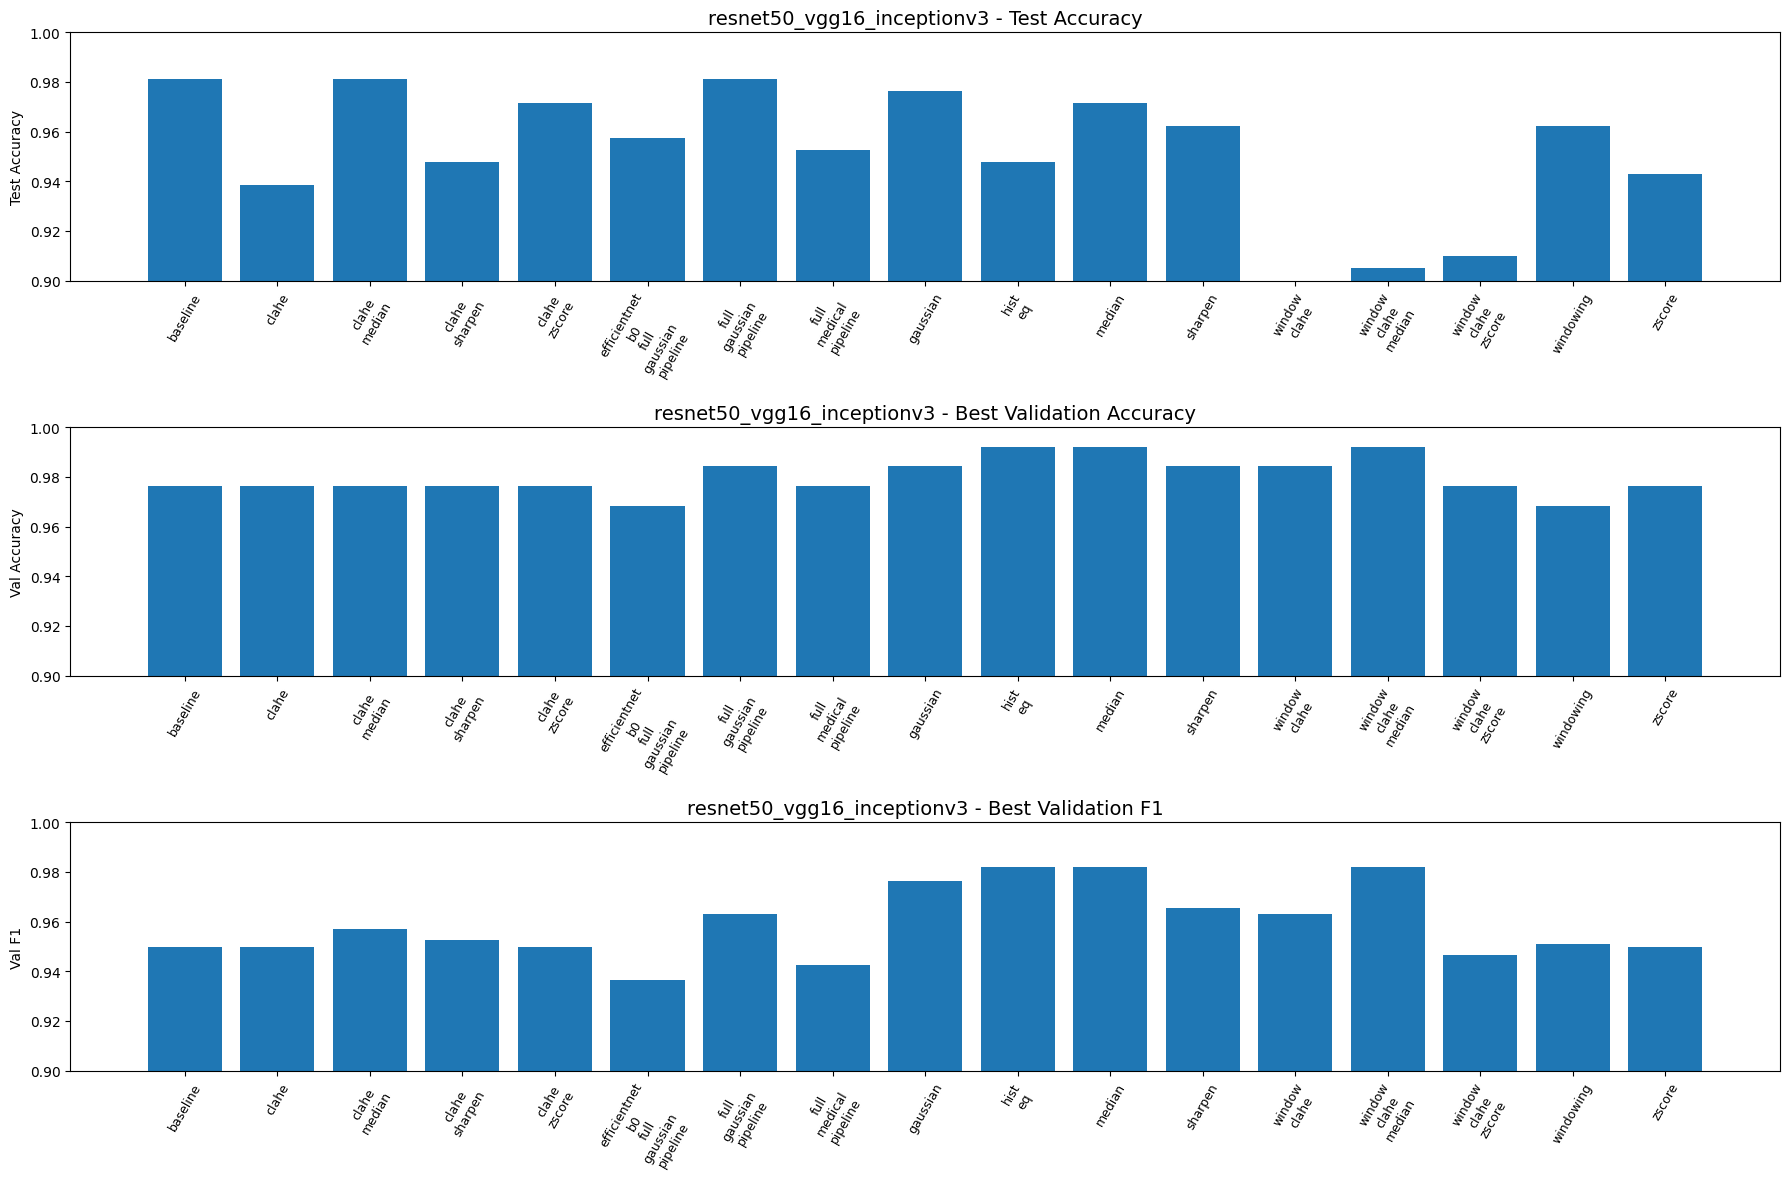

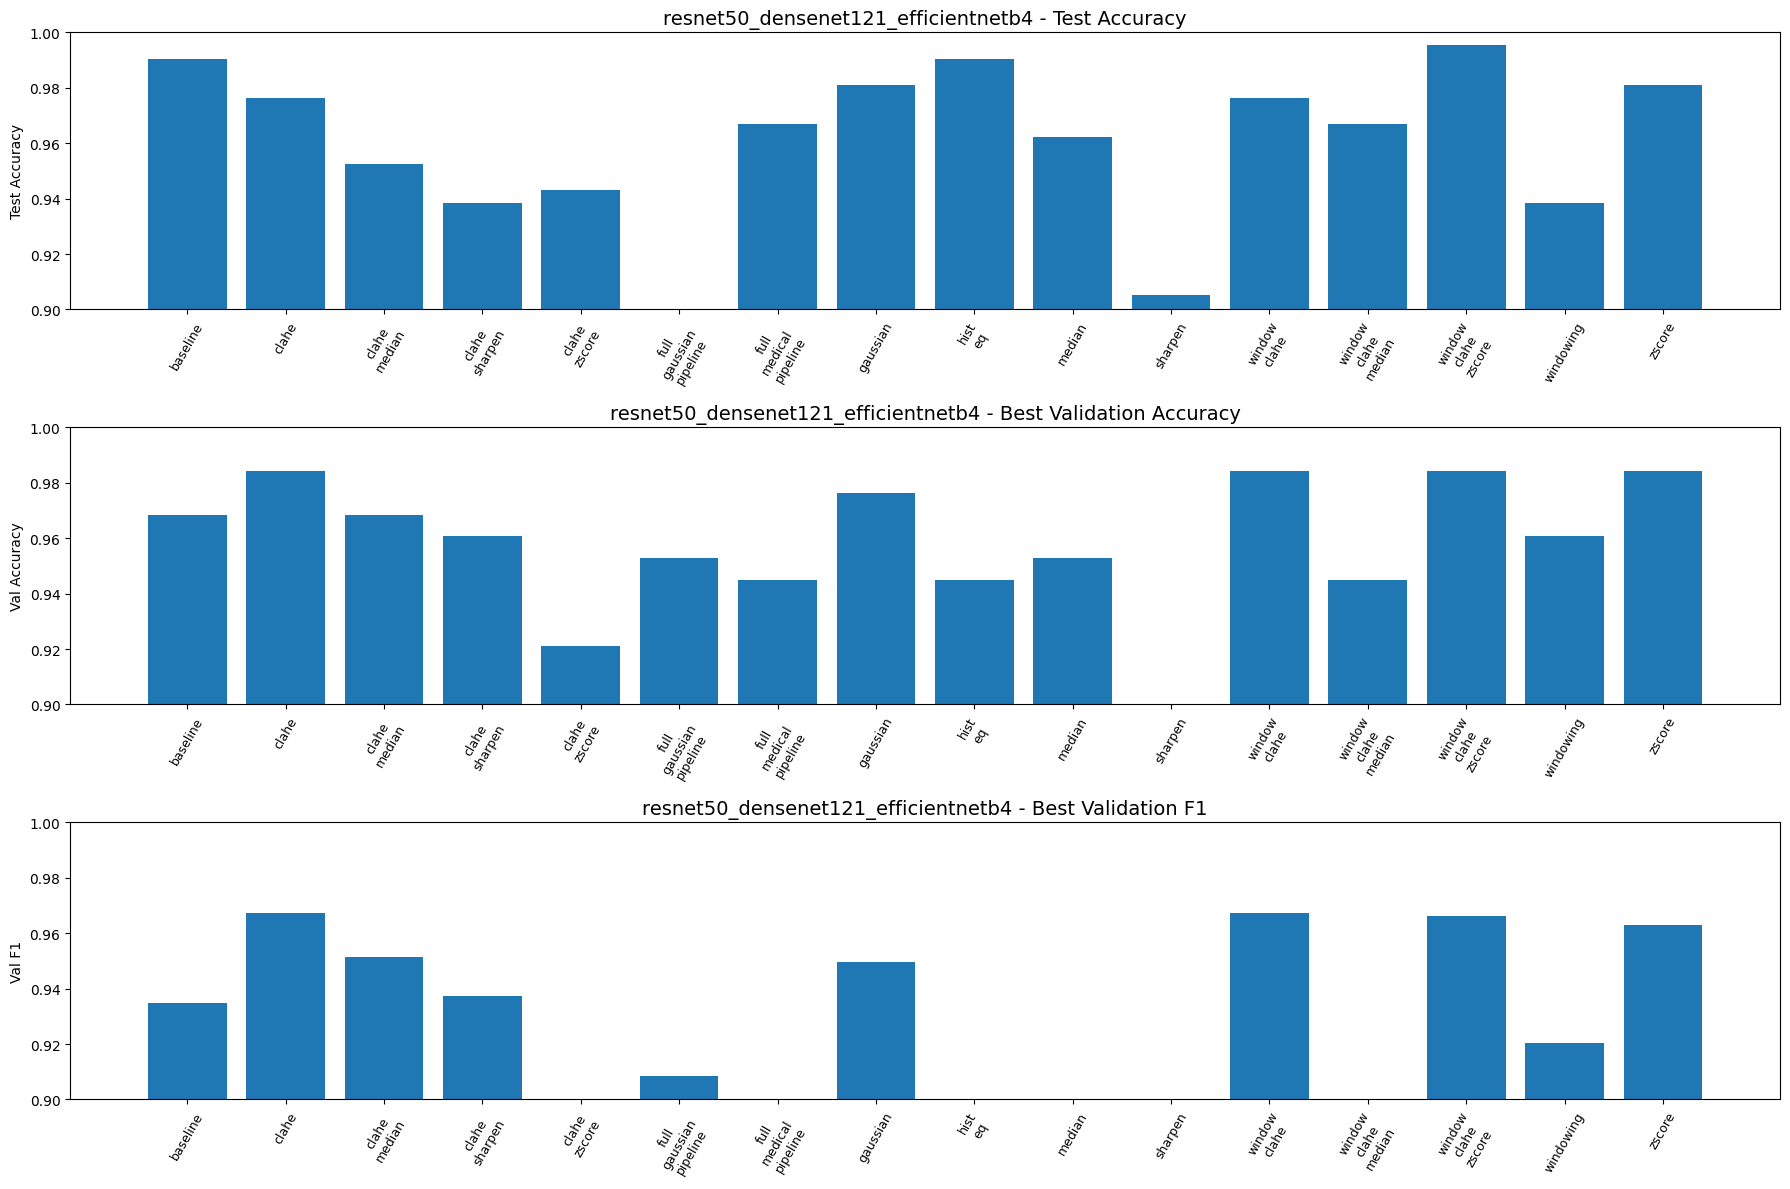

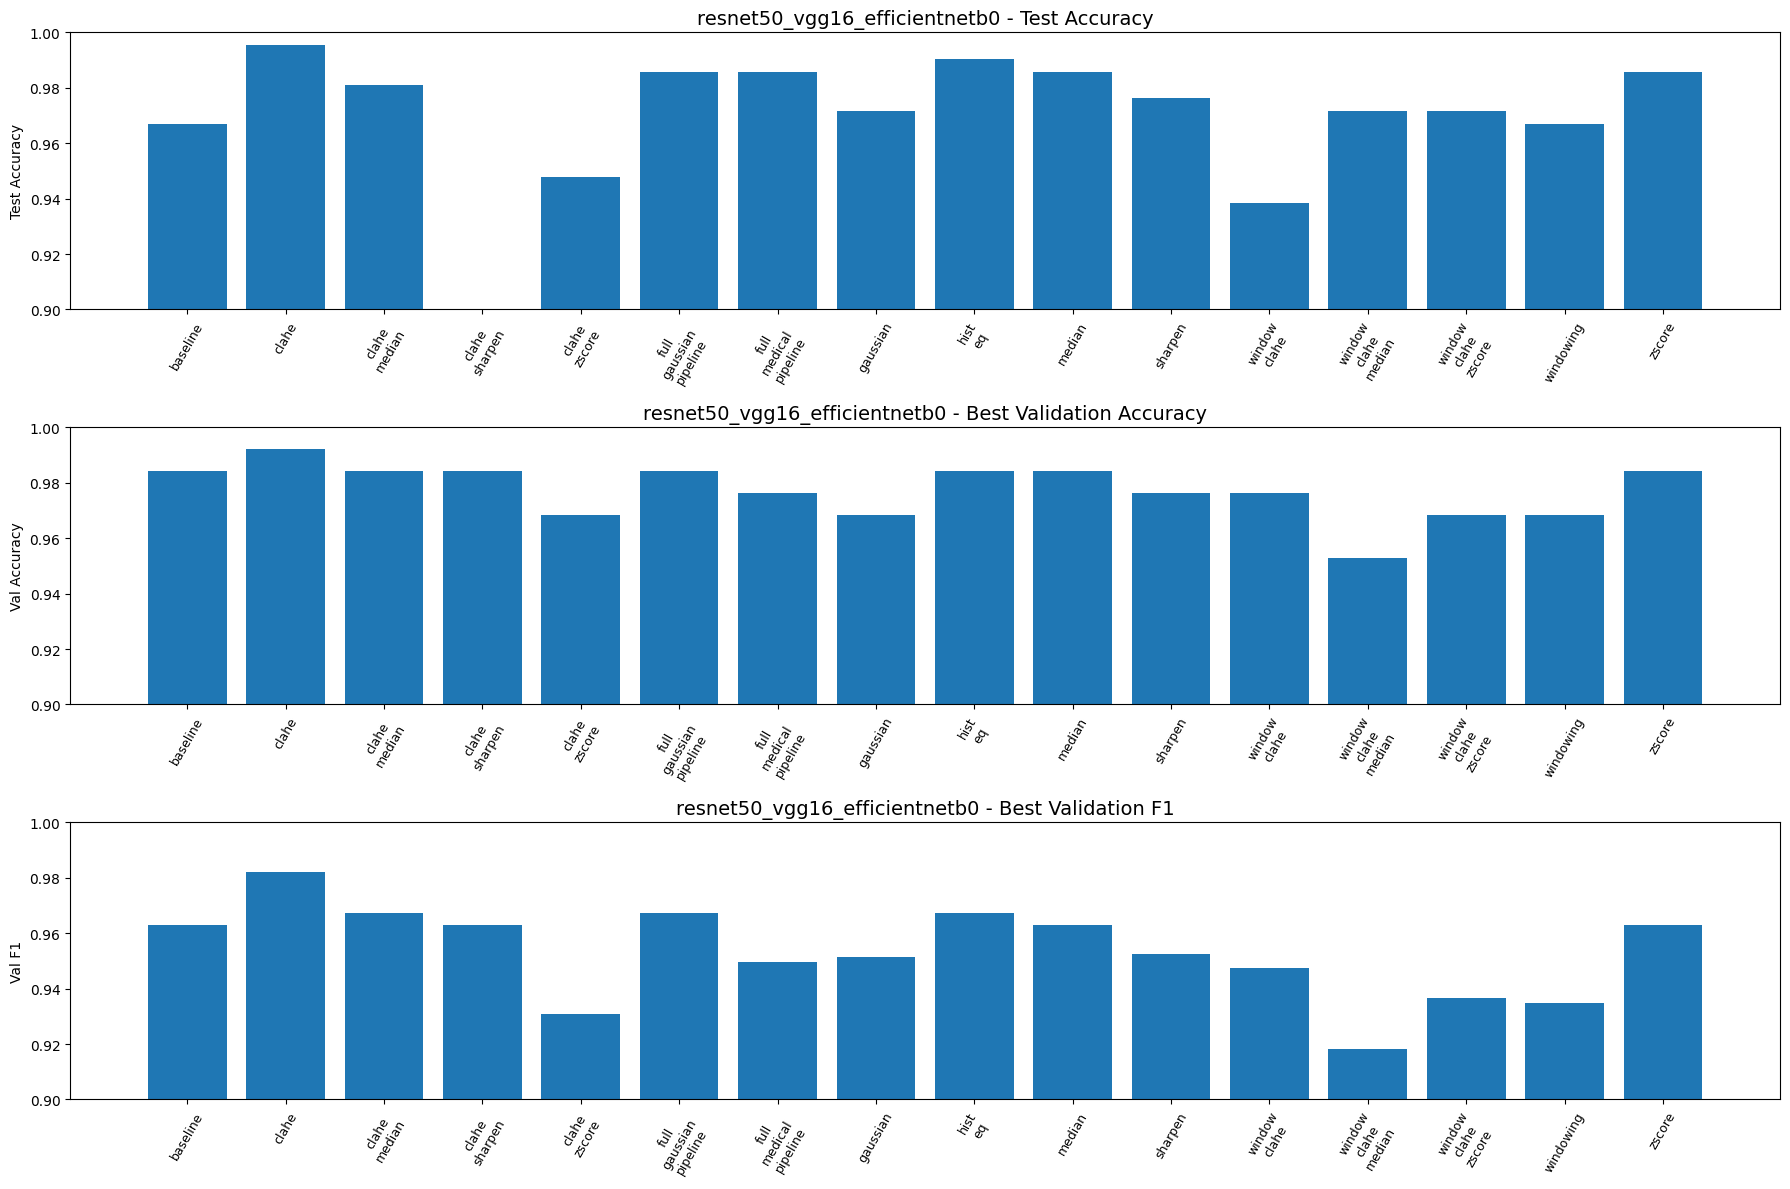

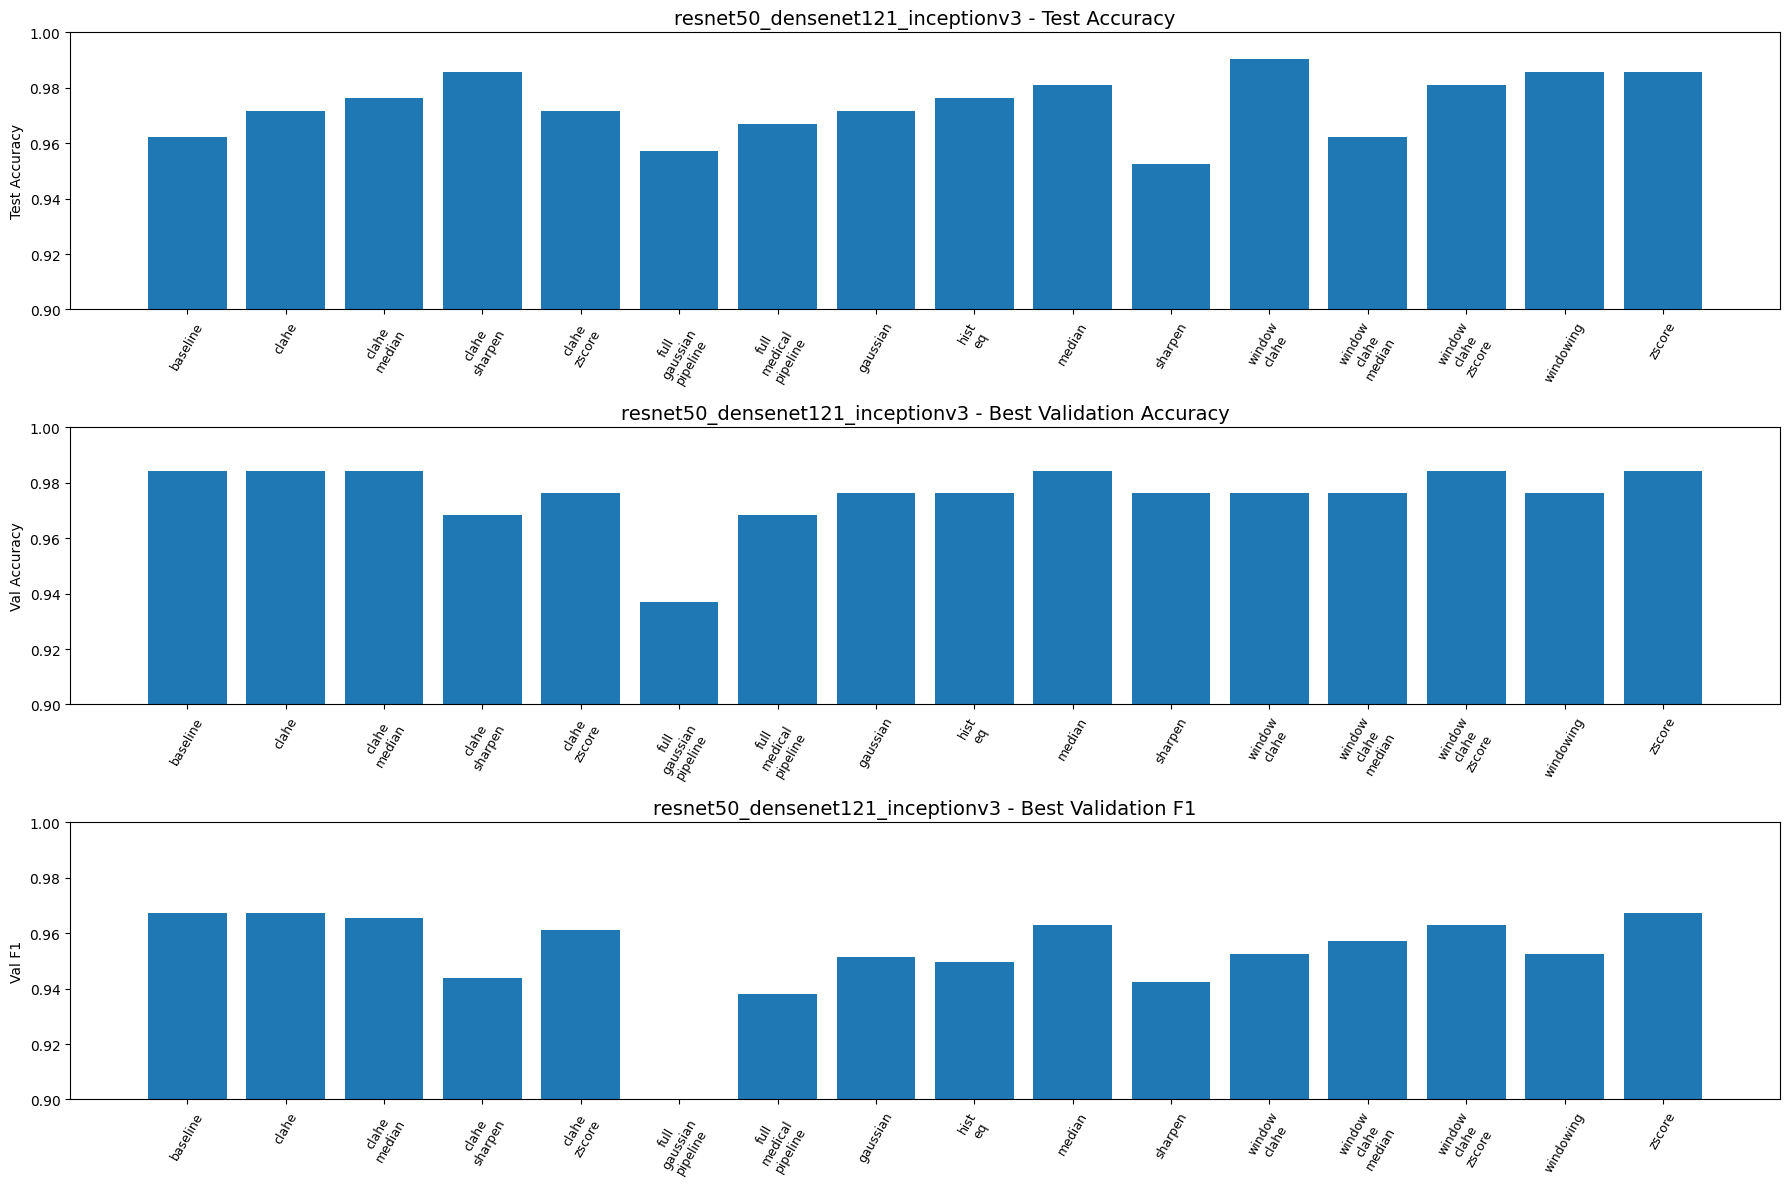

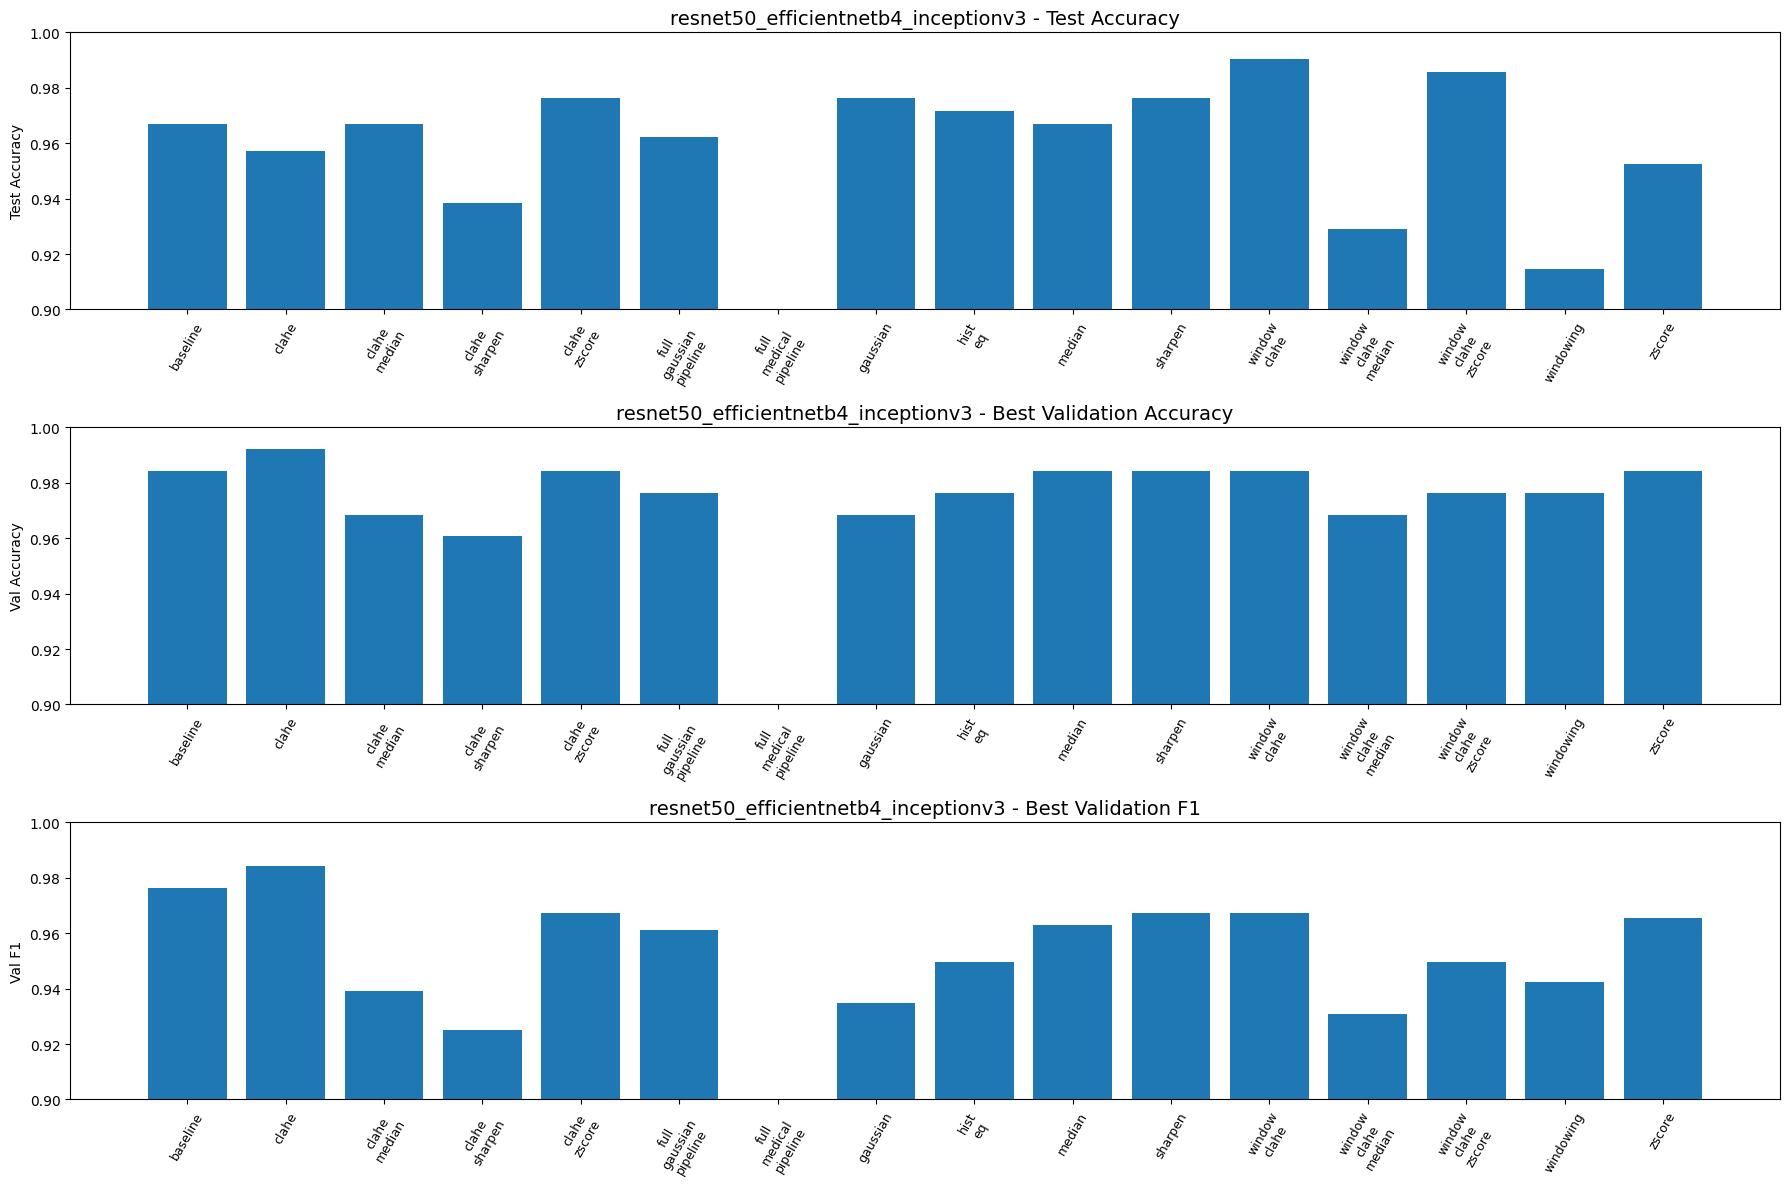

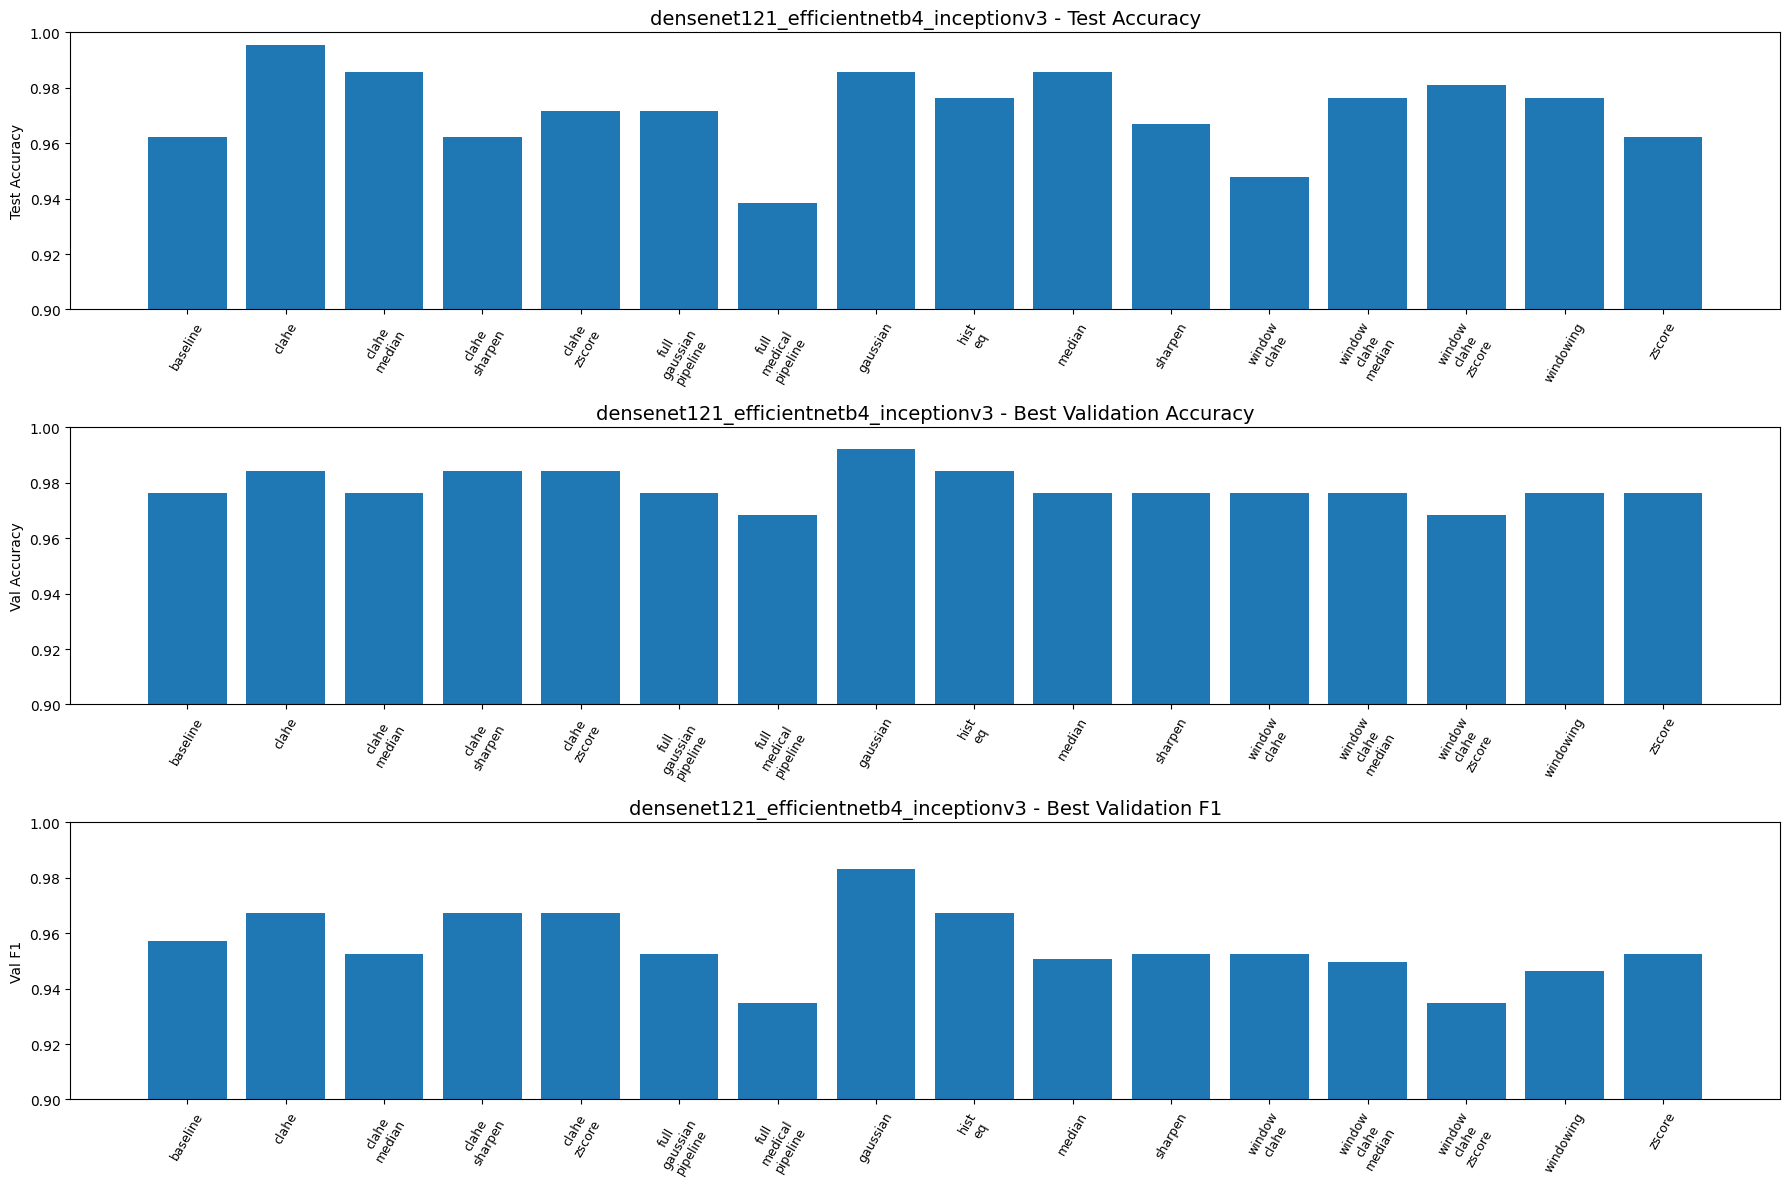

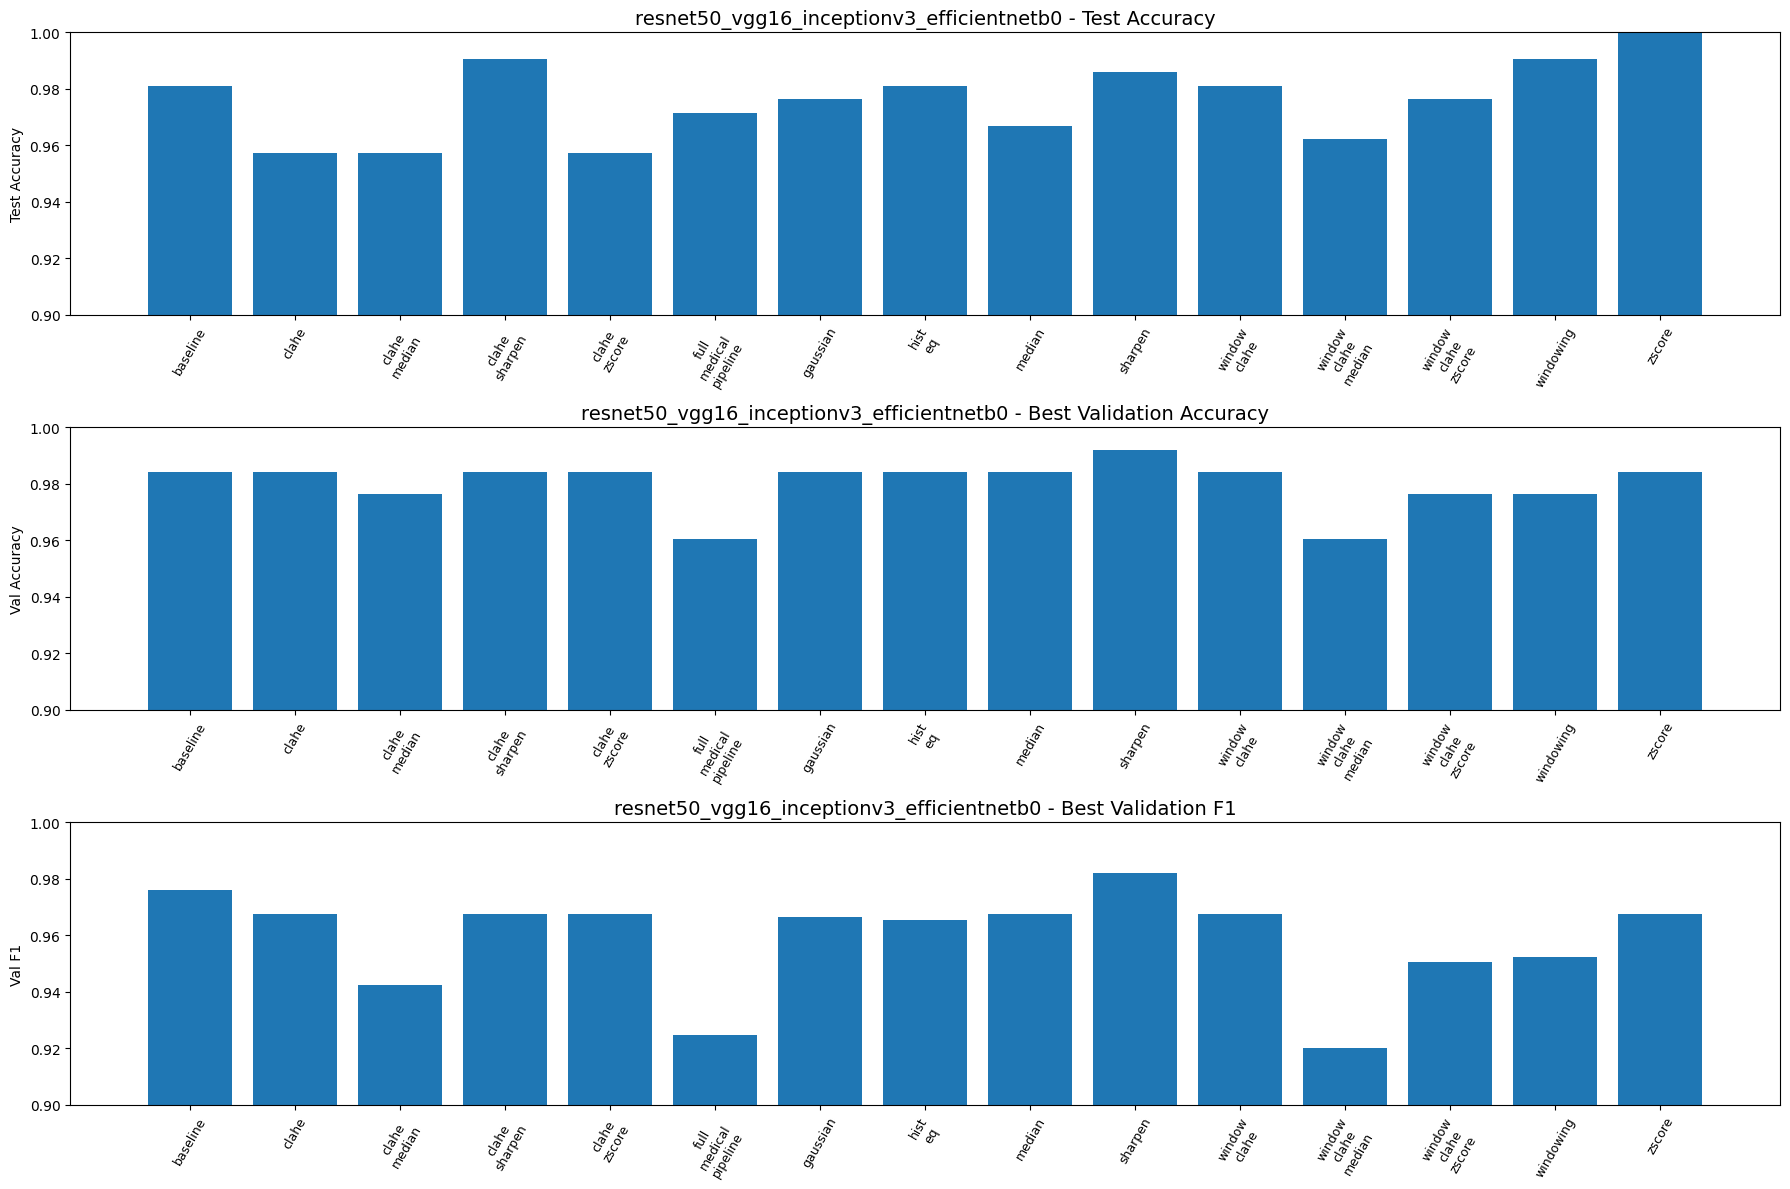

Charts generated successfully!


In [12]:
import matplotlib.pyplot as plt
import os

os.makedirs("results/charts", exist_ok=True)

models = df["hybrid_model"].unique()

for model in models:

    model_df = df[df["hybrid_model"] == model]
    model_df = model_df.sort_values("config")

    # MULTILINE LABELS (fix overlap)
    configs = [c.replace("_", "\n") for c in model_df["config"]]

    # create single figure with 3 charts
    fig, axes = plt.subplots(3, 1, figsize=(18, 12))

    # -------- Test Accuracy --------
    axes[0].bar(configs, model_df["Test_Accuracy"])
    axes[0].set_title(f"{model} - Test Accuracy", fontsize=14)
    axes[0].set_ylabel("Test Accuracy")
    axes[0].set_ylim(0.9, 1)
    axes[0].tick_params(axis='x', rotation=60, labelsize=9)

    # -------- Validation Accuracy --------
    axes[1].bar(configs, model_df["Best_Val_Accuracy"])
    axes[1].set_title(f"{model} - Best Validation Accuracy", fontsize=14)
    axes[1].set_ylabel("Val Accuracy")
    axes[1].set_ylim(0.9, 1)
    axes[1].tick_params(axis='x', rotation=60, labelsize=9)

    # -------- Validation F1 --------
    axes[2].bar(configs, model_df["Best_Val_f1"])
    axes[2].set_title(f"{model} - Best Validation F1", fontsize=14)
    axes[2].set_ylabel("Val F1")
    axes[2].set_ylim(0.9, 1)
    axes[2].tick_params(axis='x', rotation=60, labelsize=9)

    plt.tight_layout()

    plt.show()
    plt.close()

print("Charts generated successfully!")

In [13]:
# Step 1: highest validation F1 per hybrid model
best_configs = df.loc[df.groupby("hybrid_model")["Best_Val_f1"].idxmax()]

# Step 2: if tie, choose lowest validation loss
best_configs = best_configs.loc[
    best_configs.groupby("hybrid_model")["Best_Val_Loss"].idxmin()
]

print(best_configs[["hybrid_model","config","Best_Val_f1","Test_Accuracy"]])

                                  hybrid_model    config  Best_Val_f1  \
85      densenet121_efficientnetb4_inceptionv3  gaussian     0.983230   
18         resnet50_densenet121_efficientnetb4     clahe     0.967415   
48            resnet50_densenet121_inceptionv3  baseline     0.967415   
66         resnet50_efficientnetb4_inceptionv3     clahe     0.984122   
34               resnet50_vgg16_efficientnetb0     clahe     0.982140   
3                   resnet50_vgg16_inceptionv3   hist_eq     0.982140   
105  resnet50_vgg16_inceptionv3_efficientnetb0   sharpen     0.982140   

     Test_Accuracy  
85        0.985782  
18        0.976303  
48        0.962085  
66        0.957346  
34        0.995261  
3         0.947867  
105       0.985782  


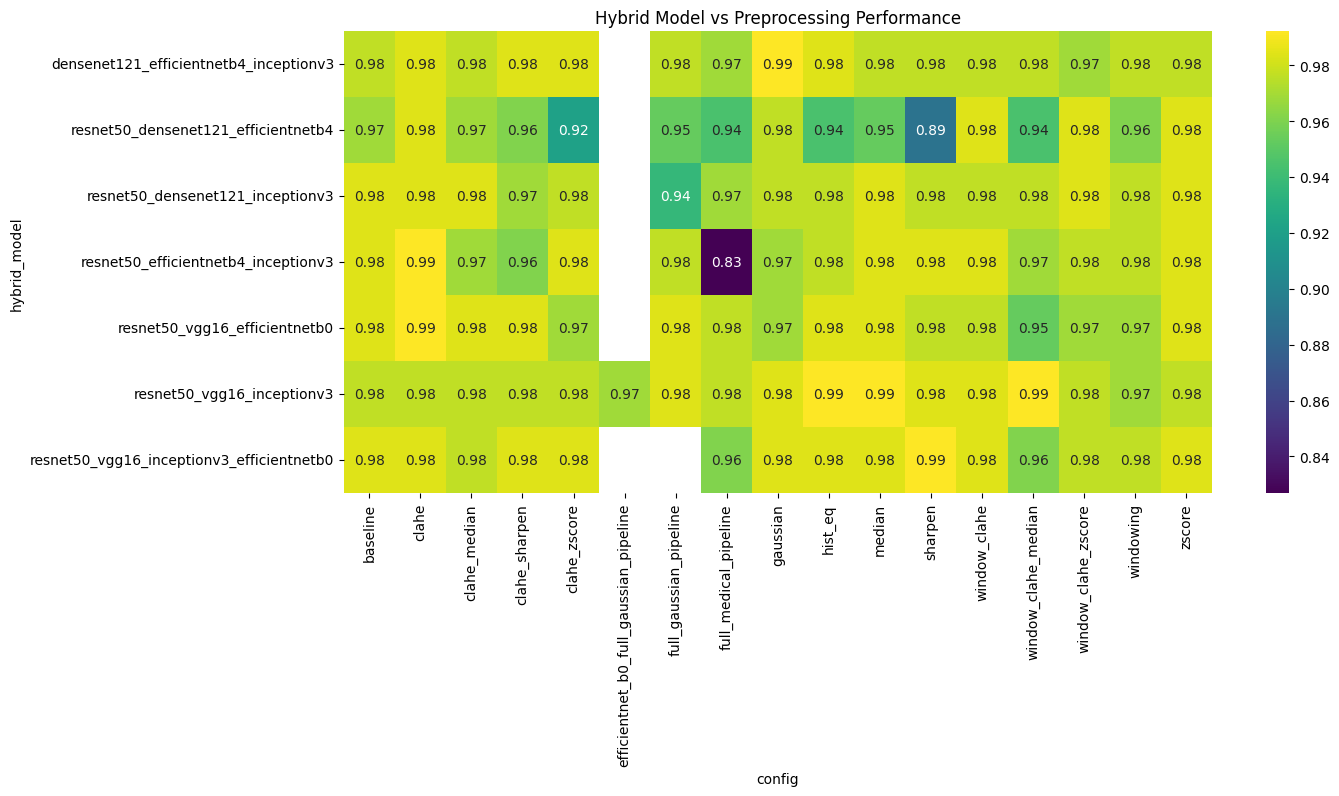

In [14]:
import seaborn as sns

pivot = df.pivot(index="hybrid_model", columns="config", values="Best_Val_Accuracy")

plt.figure(figsize=(14,6))
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("Hybrid Model vs Preprocessing Performance")
plt.show()

['densenet121\nefficientnetb4\ninceptionv3', 'resnet50\ndensenet121\nefficientnetb4', 'resnet50\ndensenet121\ninceptionv3', 'resnet50\nefficientnetb4\ninceptionv3', 'resnet50\nvgg16\nefficientnetb0', 'resnet50\nvgg16\ninceptionv3', 'resnet50\nvgg16\ninceptionv3\nefficientnetb0']


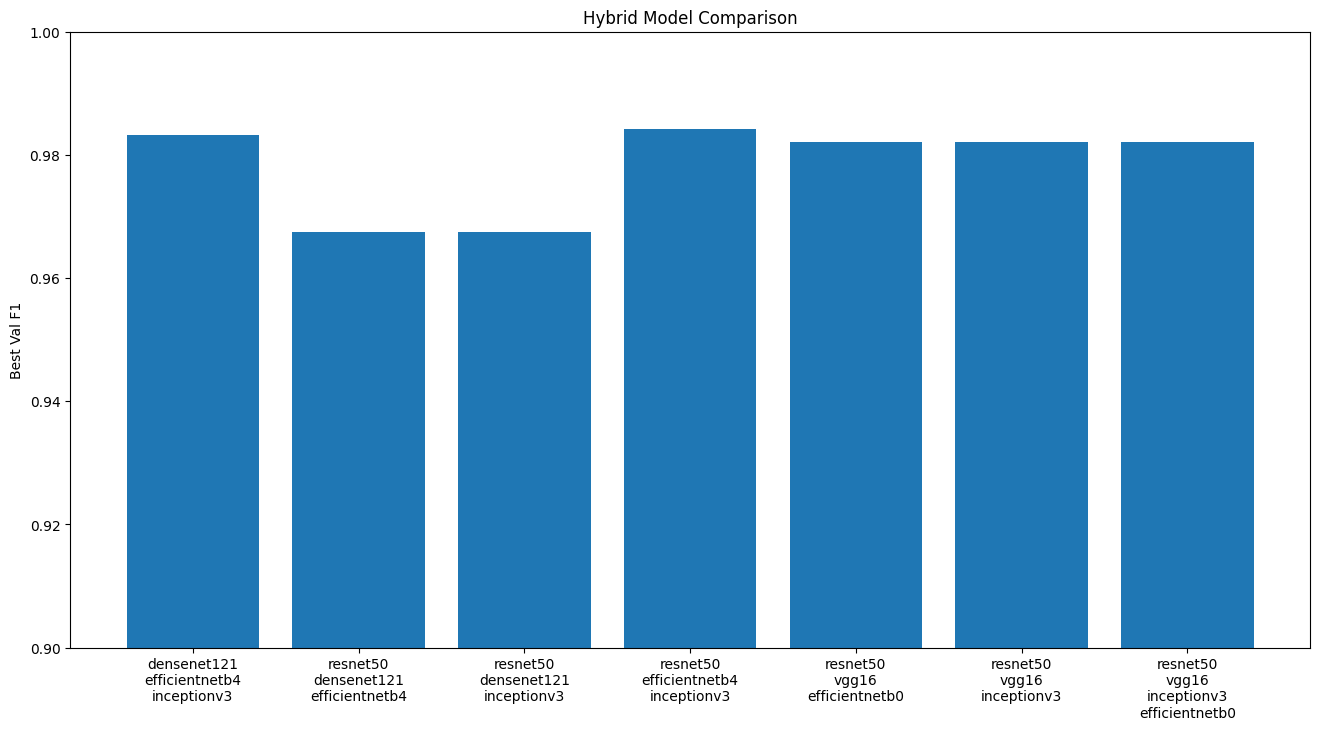

In [24]:
best_models = df.loc[df.groupby("hybrid_model")["Best_Val_f1"].idxmax()]
# print(best_models)
os.makedirs("results/charts/comparison",exist_ok=True)
config = [c.replace("_", "\n") for c in best_models["hybrid_model"]]
print(config)

plt.figure(figsize=(16,8))
plt.bar(config, best_models["Best_Val_f1"])
plt.xticks(rotation=0)
plt.ylabel("Best Val F1")
plt.ylim(0.90,1)
plt.savefig("results/charts/comparison/hybrid_model_comparison.png")
plt.title("Hybrid Model Comparison")
plt.show()

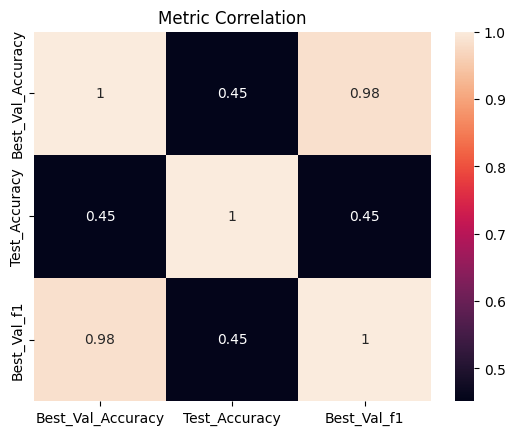

In [28]:
import seaborn as sns

corr = df[["Best_Val_Accuracy","Test_Accuracy","Best_Val_f1"]].corr()

sns.heatmap(corr, annot=True)
plt.title("Metric Correlation")
plt.show()

In [29]:
config_perf = df.groupby("config")["Best_Val_f1"].mean().sort_values(ascending=False)

print(config_perf)

config
clahe                     0.969373
zscore                    0.961205
baseline                  0.960636
window_clahe              0.959637
gaussian                  0.959051
median                    0.954313
hist_eq                   0.954187
clahe_median              0.953664
clahe_sharpen             0.950956
window_clahe_zscore       0.949671
windowing                 0.942867
sharpen                   0.942086
clahe_zscore              0.941811
full_gaussian_pipeline    0.940571
window_clahe_median       0.935457
full_medical_pipeline     0.900171
Name: Best_Val_f1, dtype: float64


In [31]:
df["score"] = df["Best_Val_f1"] * 0.7 + df["Test_Accuracy"] * 0.3

best_configs = df.loc[df.groupby("hybrid_model")["score"].idxmax()]

In [32]:
best_configs

,Model,Test_Accuracy,Best_Val_Accuracy,Best_Val_f1,Best_Val_Loss,Precision,Recall,F1,Epochs,prep_windowing,prep_clahe,prep_hist_eq,prep_gaussian,prep_median,prep_sharpen_flag,prep_norm_type,hybrid_model,config,epoch,score
85,densenet121_efficientnetb4_inceptionv3_gaussia...,0.985782,0.992126,0.983230,0.054098,0.986644,0.985782,0.985964,30,NaN,NaN,NaN,True,NaN,NaN,NaN,densenet121_efficientnetb4_inceptionv3,gaussian,30,0.983996
29,resnet50_densenet121_efficientnetb4_window_cla...,0.995261,0.984252,0.966311,0.139632,0.995486,0.995261,0.995304,30,True,True,NaN,NaN,NaN,NaN,zscore,resnet50_densenet121_efficientnetb4,window_clahe_zscore,30,0.974996
59,resnet50_densenet121_inceptionv3_zscore_ep30,0.985782,0.984252,0.967415,0.112014,0.986174,0.985782,0.985911,30,NaN,NaN,NaN,NaN,NaN,NaN,zscore,resnet50_densenet121_inceptionv3,zscore,30,0.972925
66,resnet50_efficientnetb4_inceptionv3_clahe_ep30,0.957346,0.992126,0.984122,0.089254,0.966727,0.957346,0.959559,30,NaN,True,NaN,NaN,NaN,NaN,NaN,resnet50_efficientnetb4_inceptionv3,clahe,30,0.976089
34,resnet50_vgg16_efficientnetb0_clahe_ep30,0.995261,0.992126,0.982140,0.048371,0.995318,0.995261,0.995214,30,NaN,True,NaN,NaN,NaN,NaN,NaN,resnet50_vgg16_efficientnetb0,clahe,30,0.986076
5,resnet50_vgg16_inceptionv3_median_ep30,0.971564,0.992126,0.982140,0.065646,0.973047,0.971564,0.972063,30,NaN,NaN,NaN,NaN,True,NaN,NaN,resnet50_vgg16_inceptionv3,median,30,0.978967
105,resnet50_vgg16_inceptionv3_efficientnetb0_shar...,0.985782,0.992126,0.982140,0.054808,0.986174,0.985782,0.985911,30,NaN,NaN,NaN,NaN,NaN,True,NaN,resnet50_vgg16_inceptionv3_efficientnetb0,sharpen,30,0.983233


C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


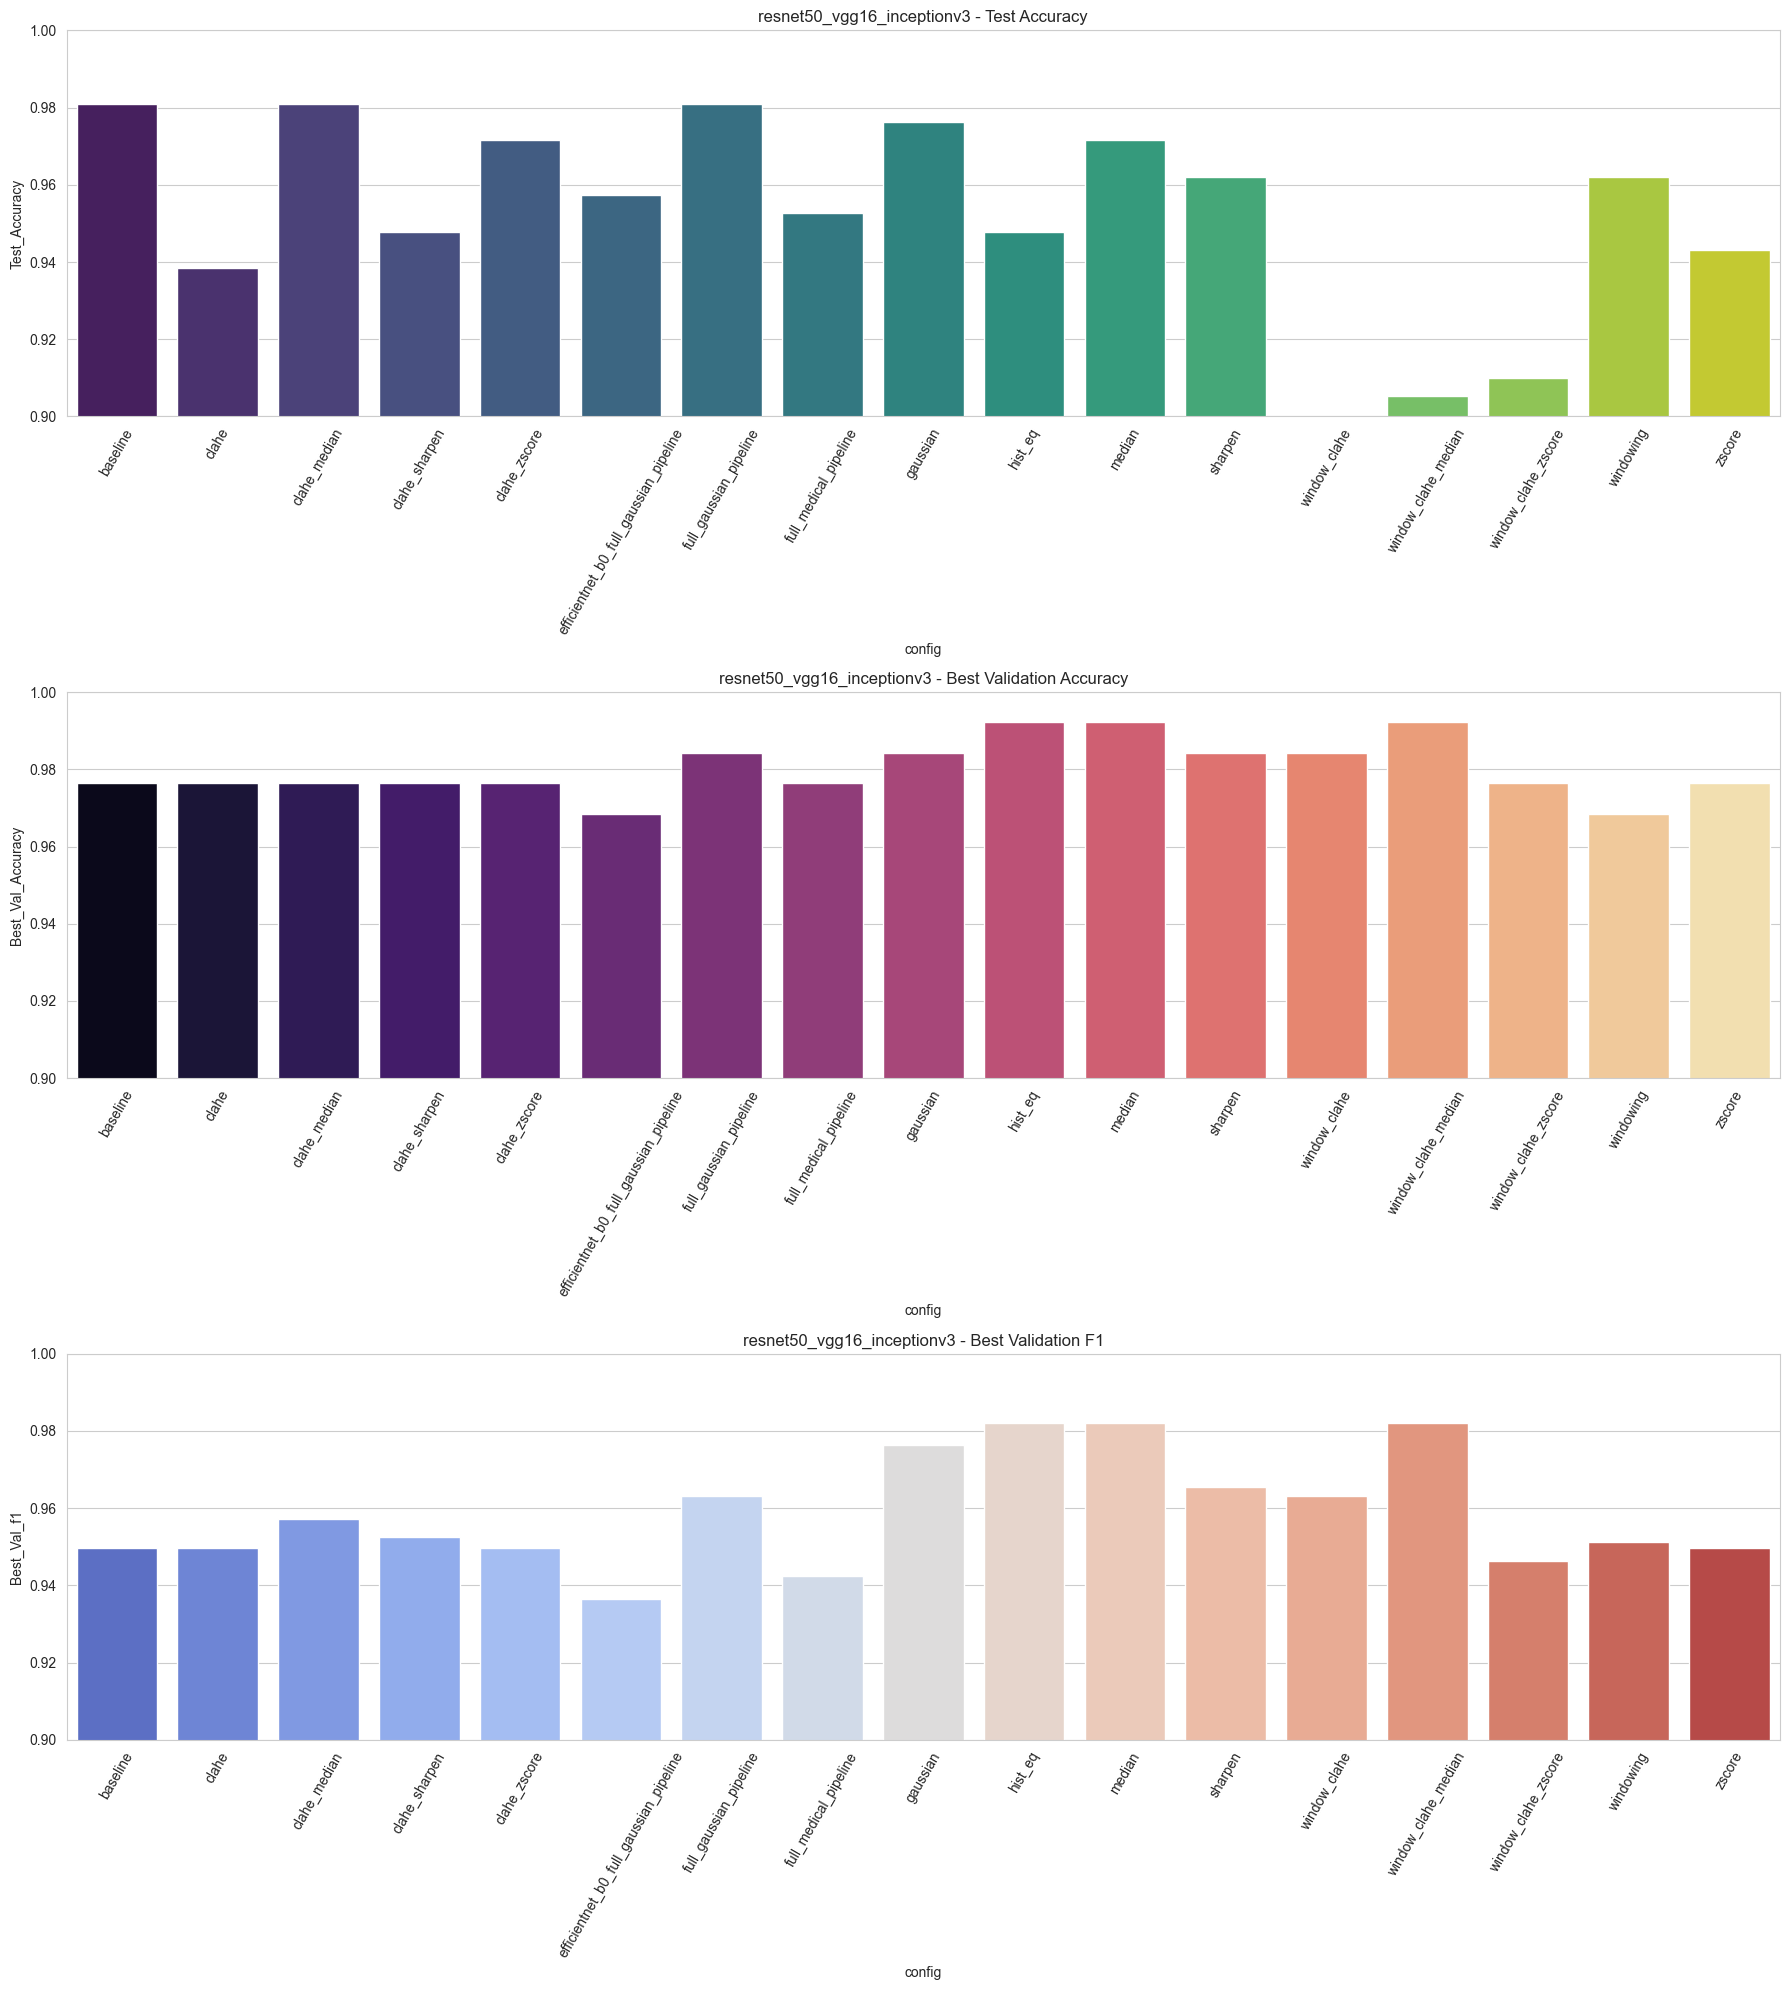

C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


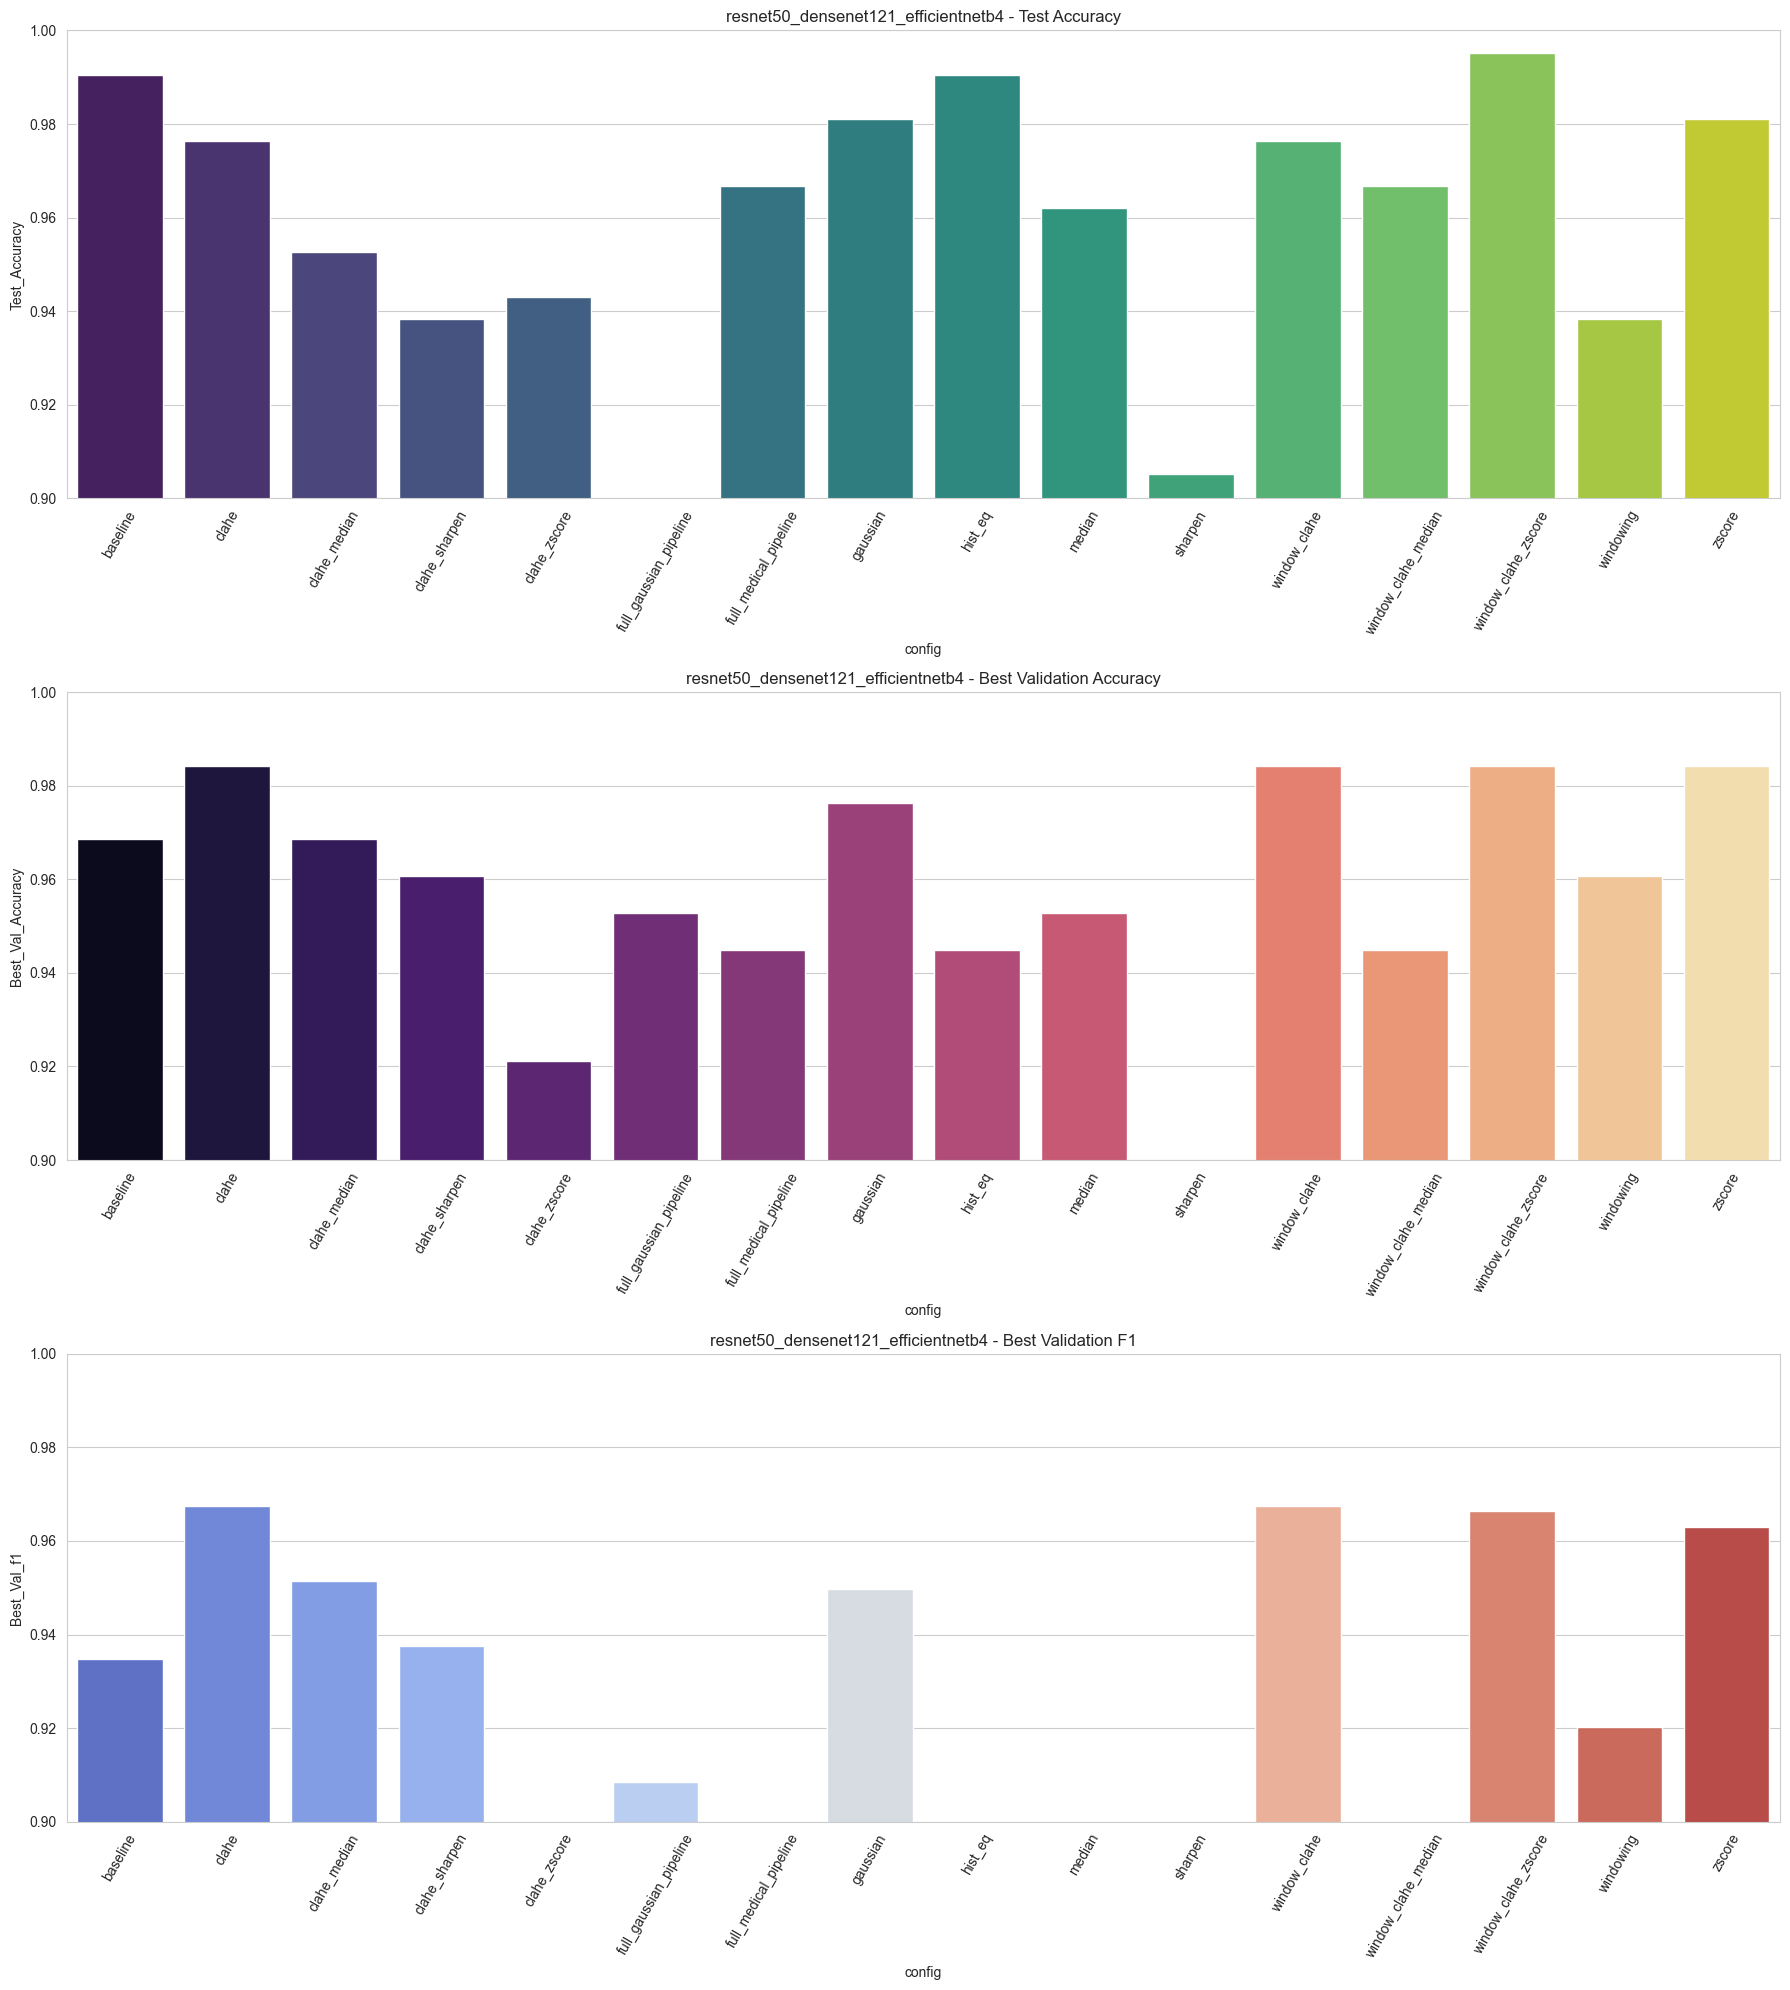

C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


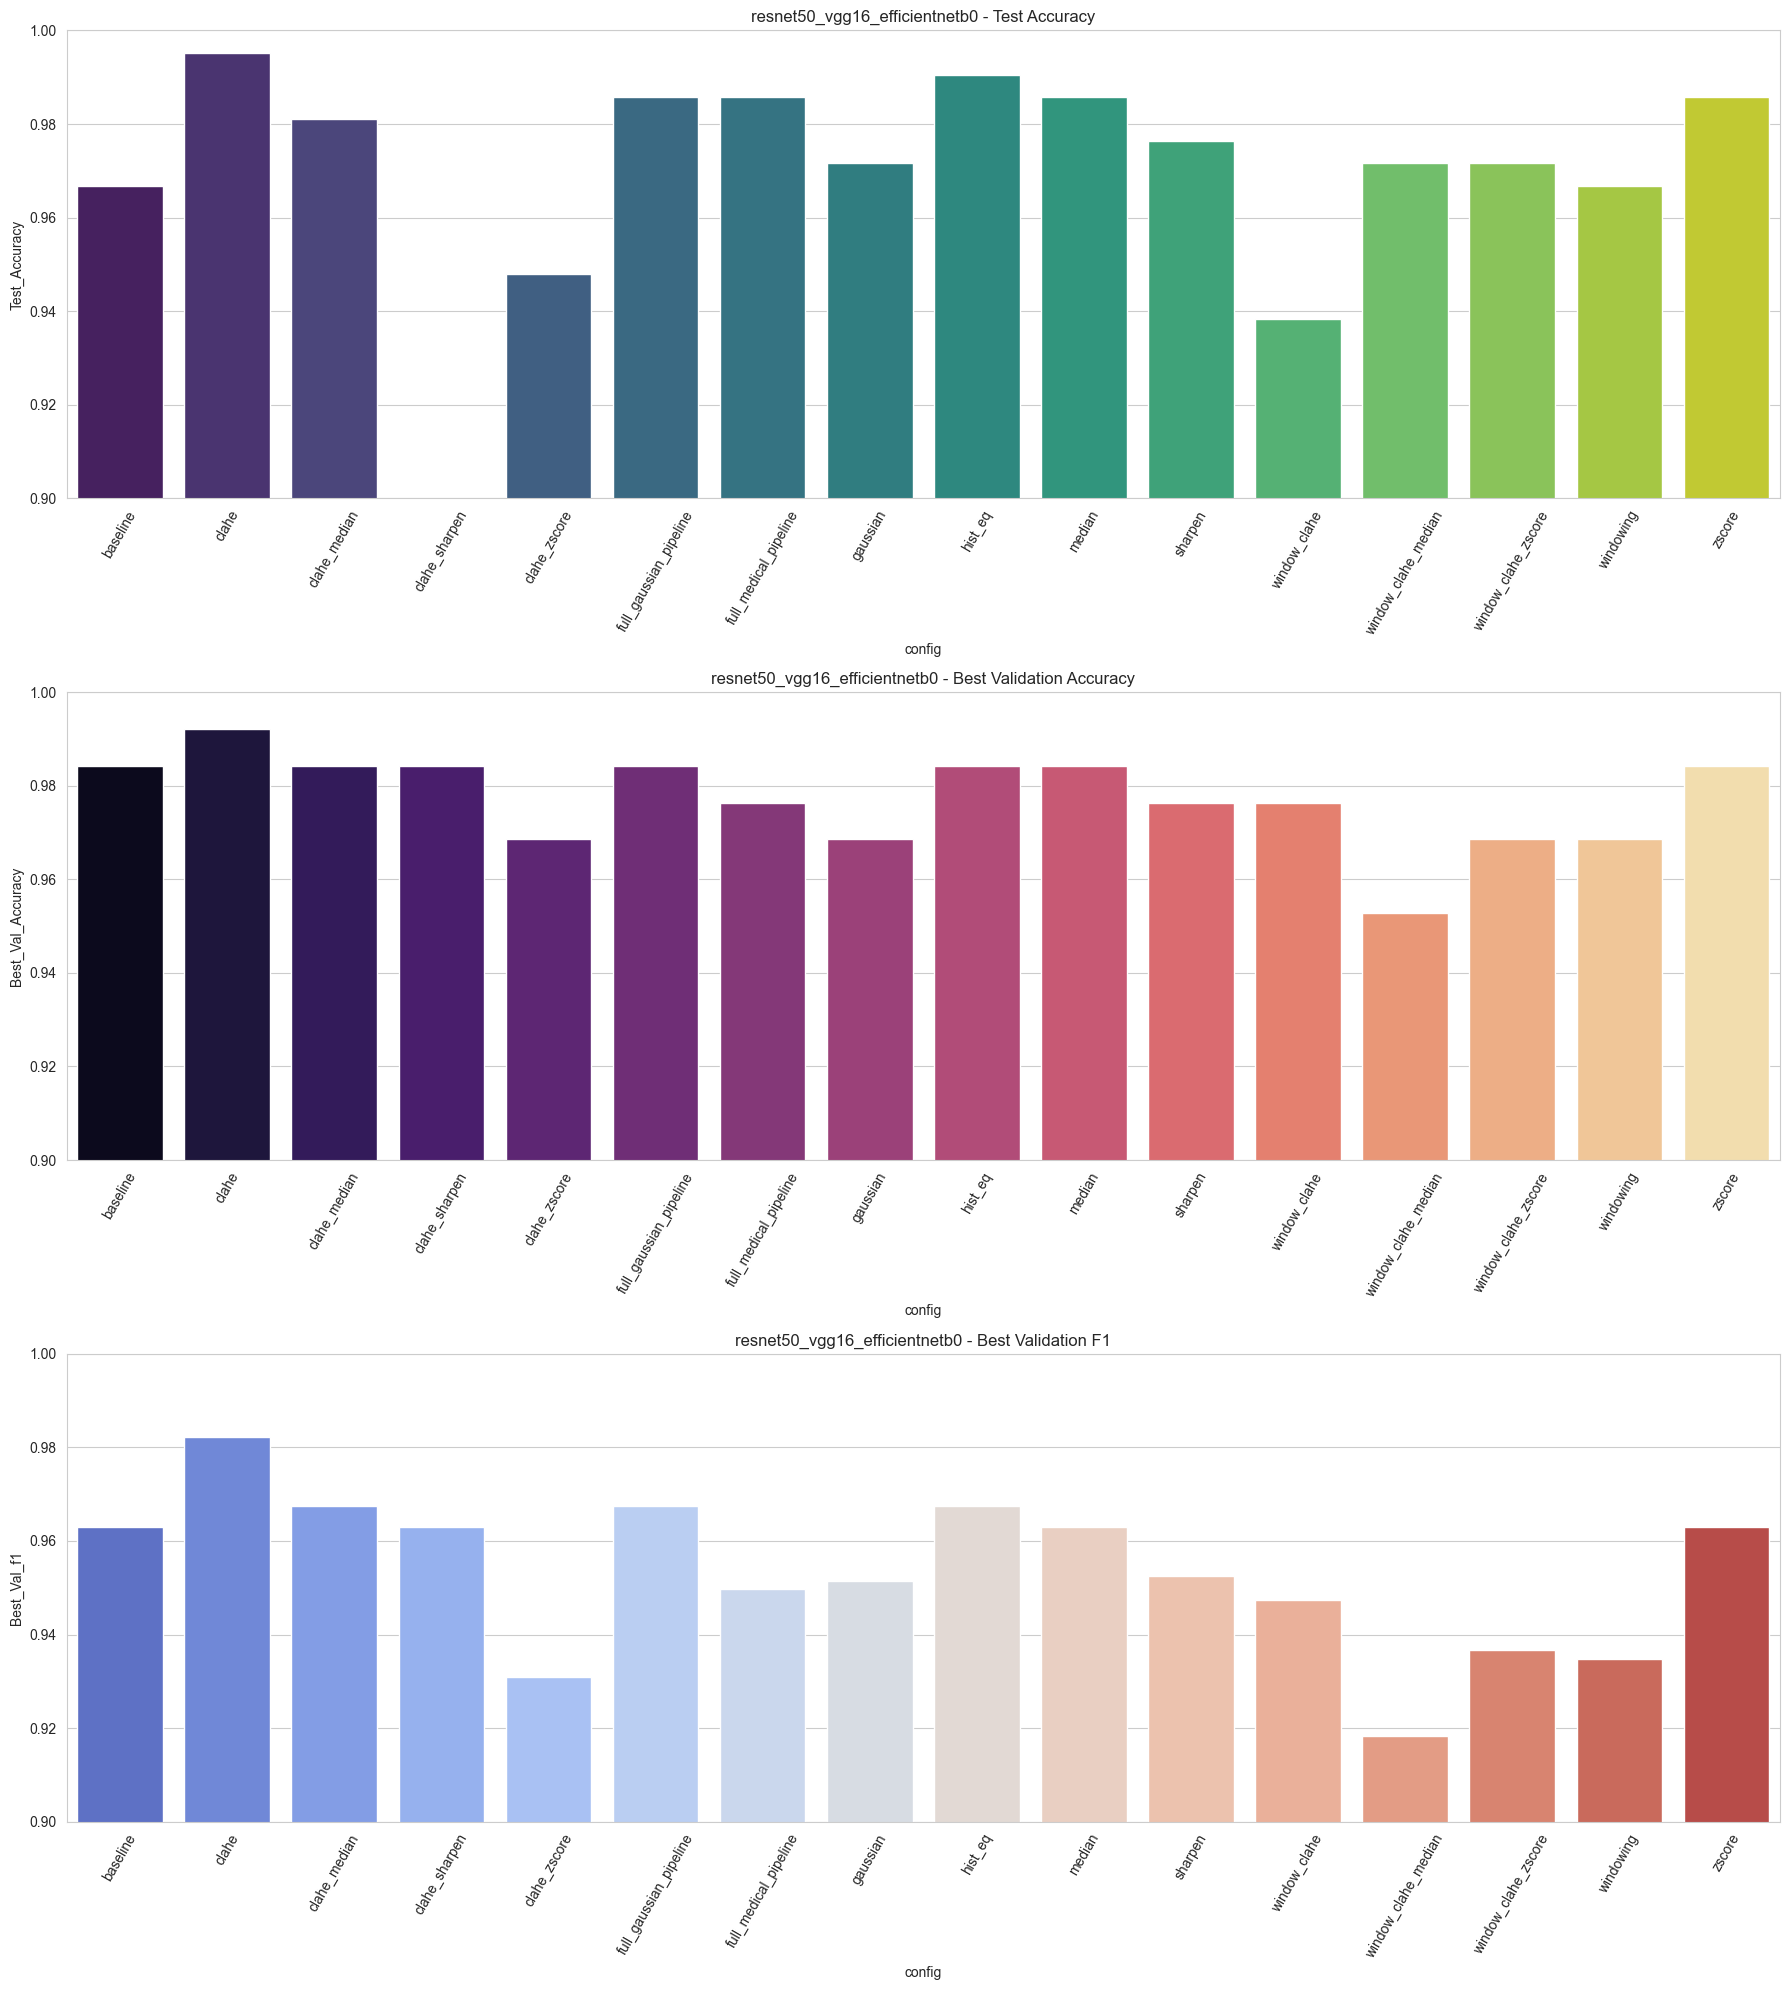

C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


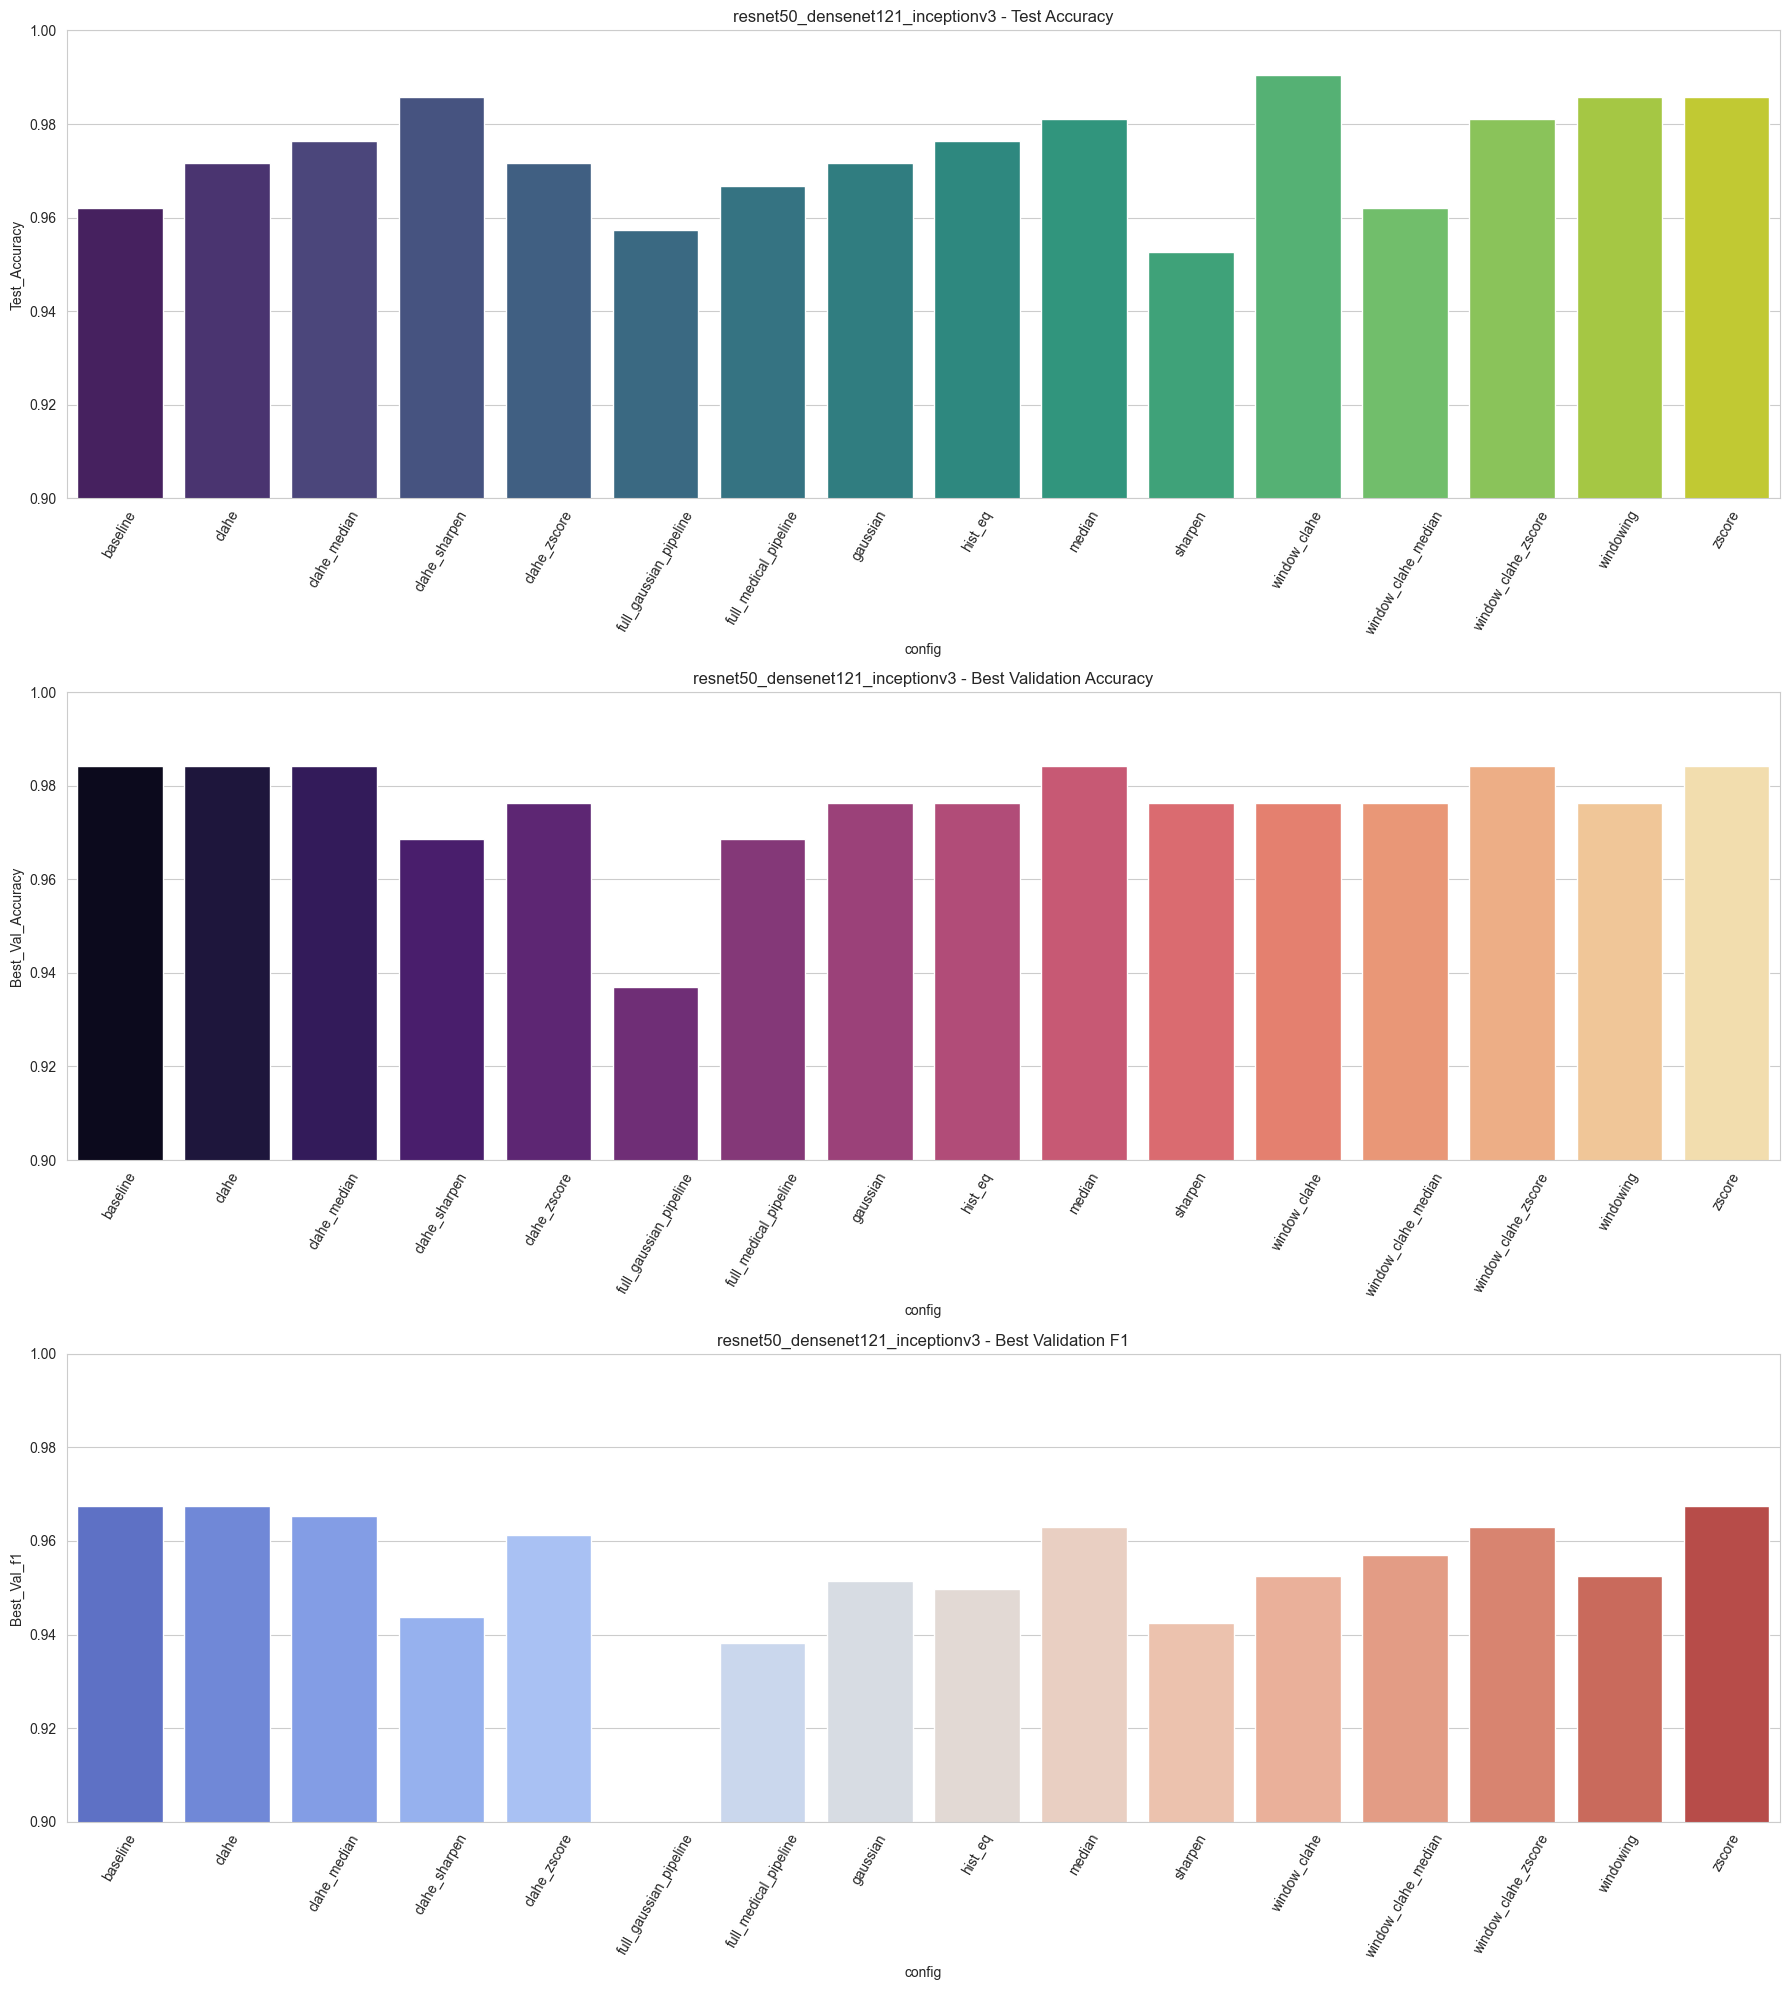

C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


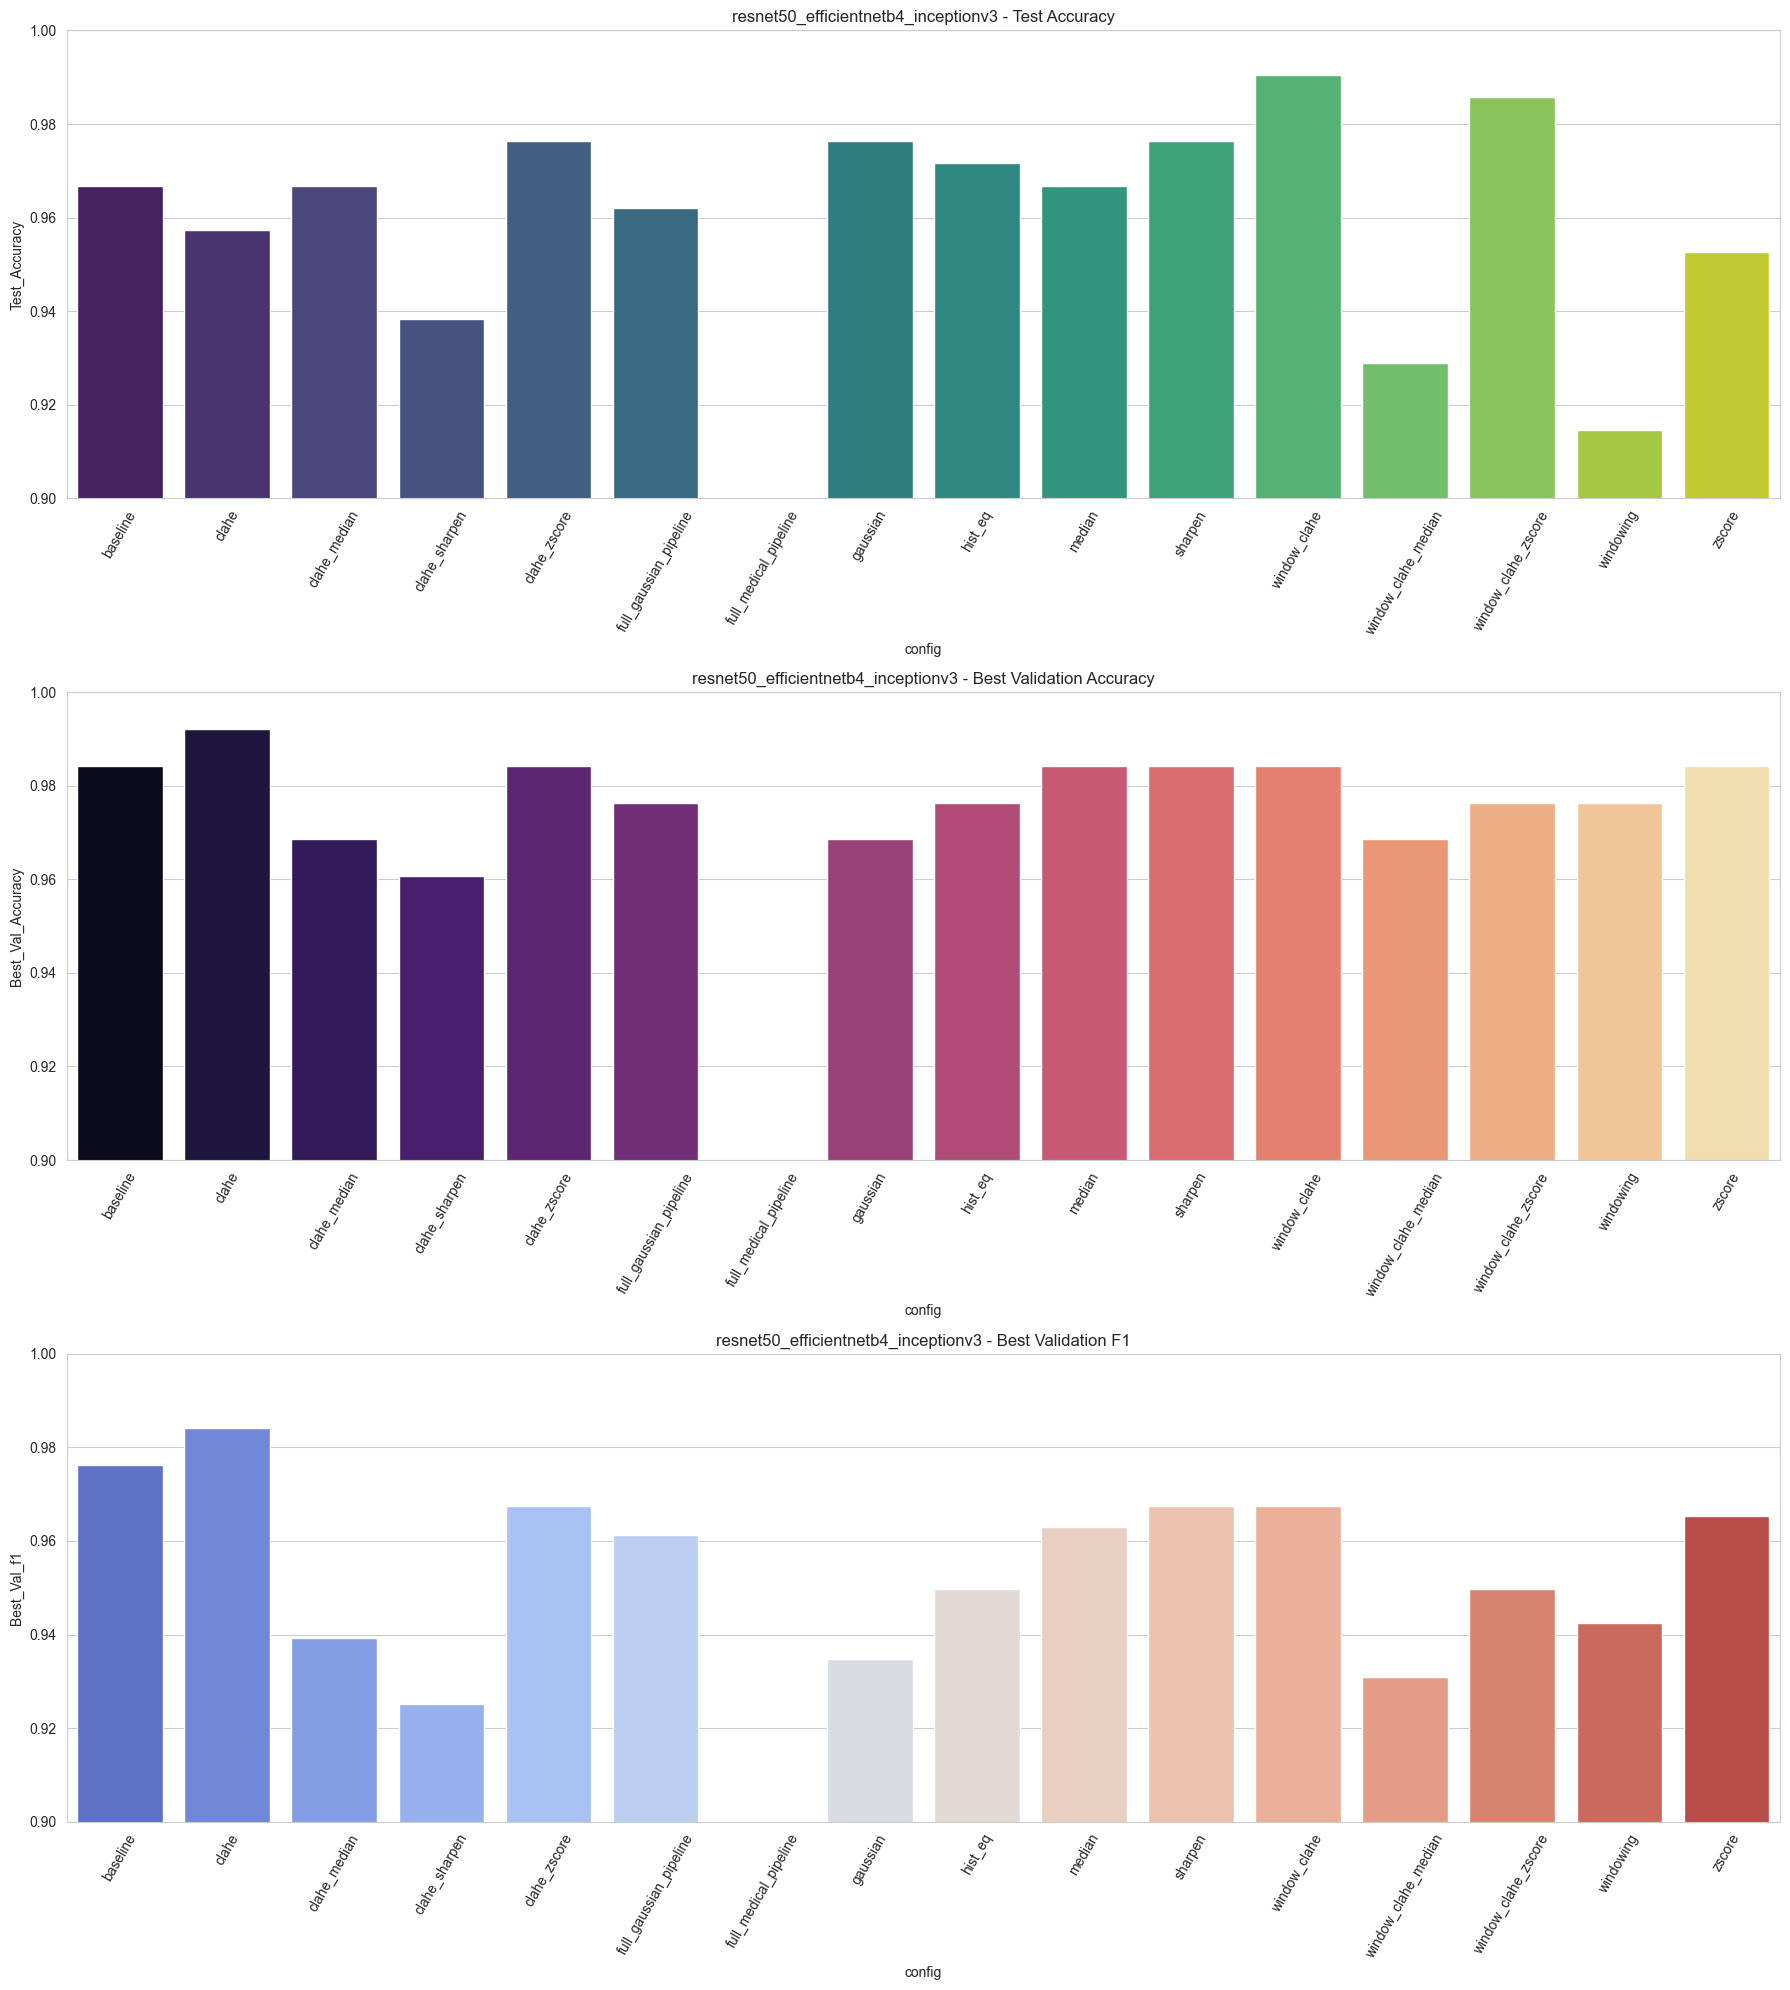

C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


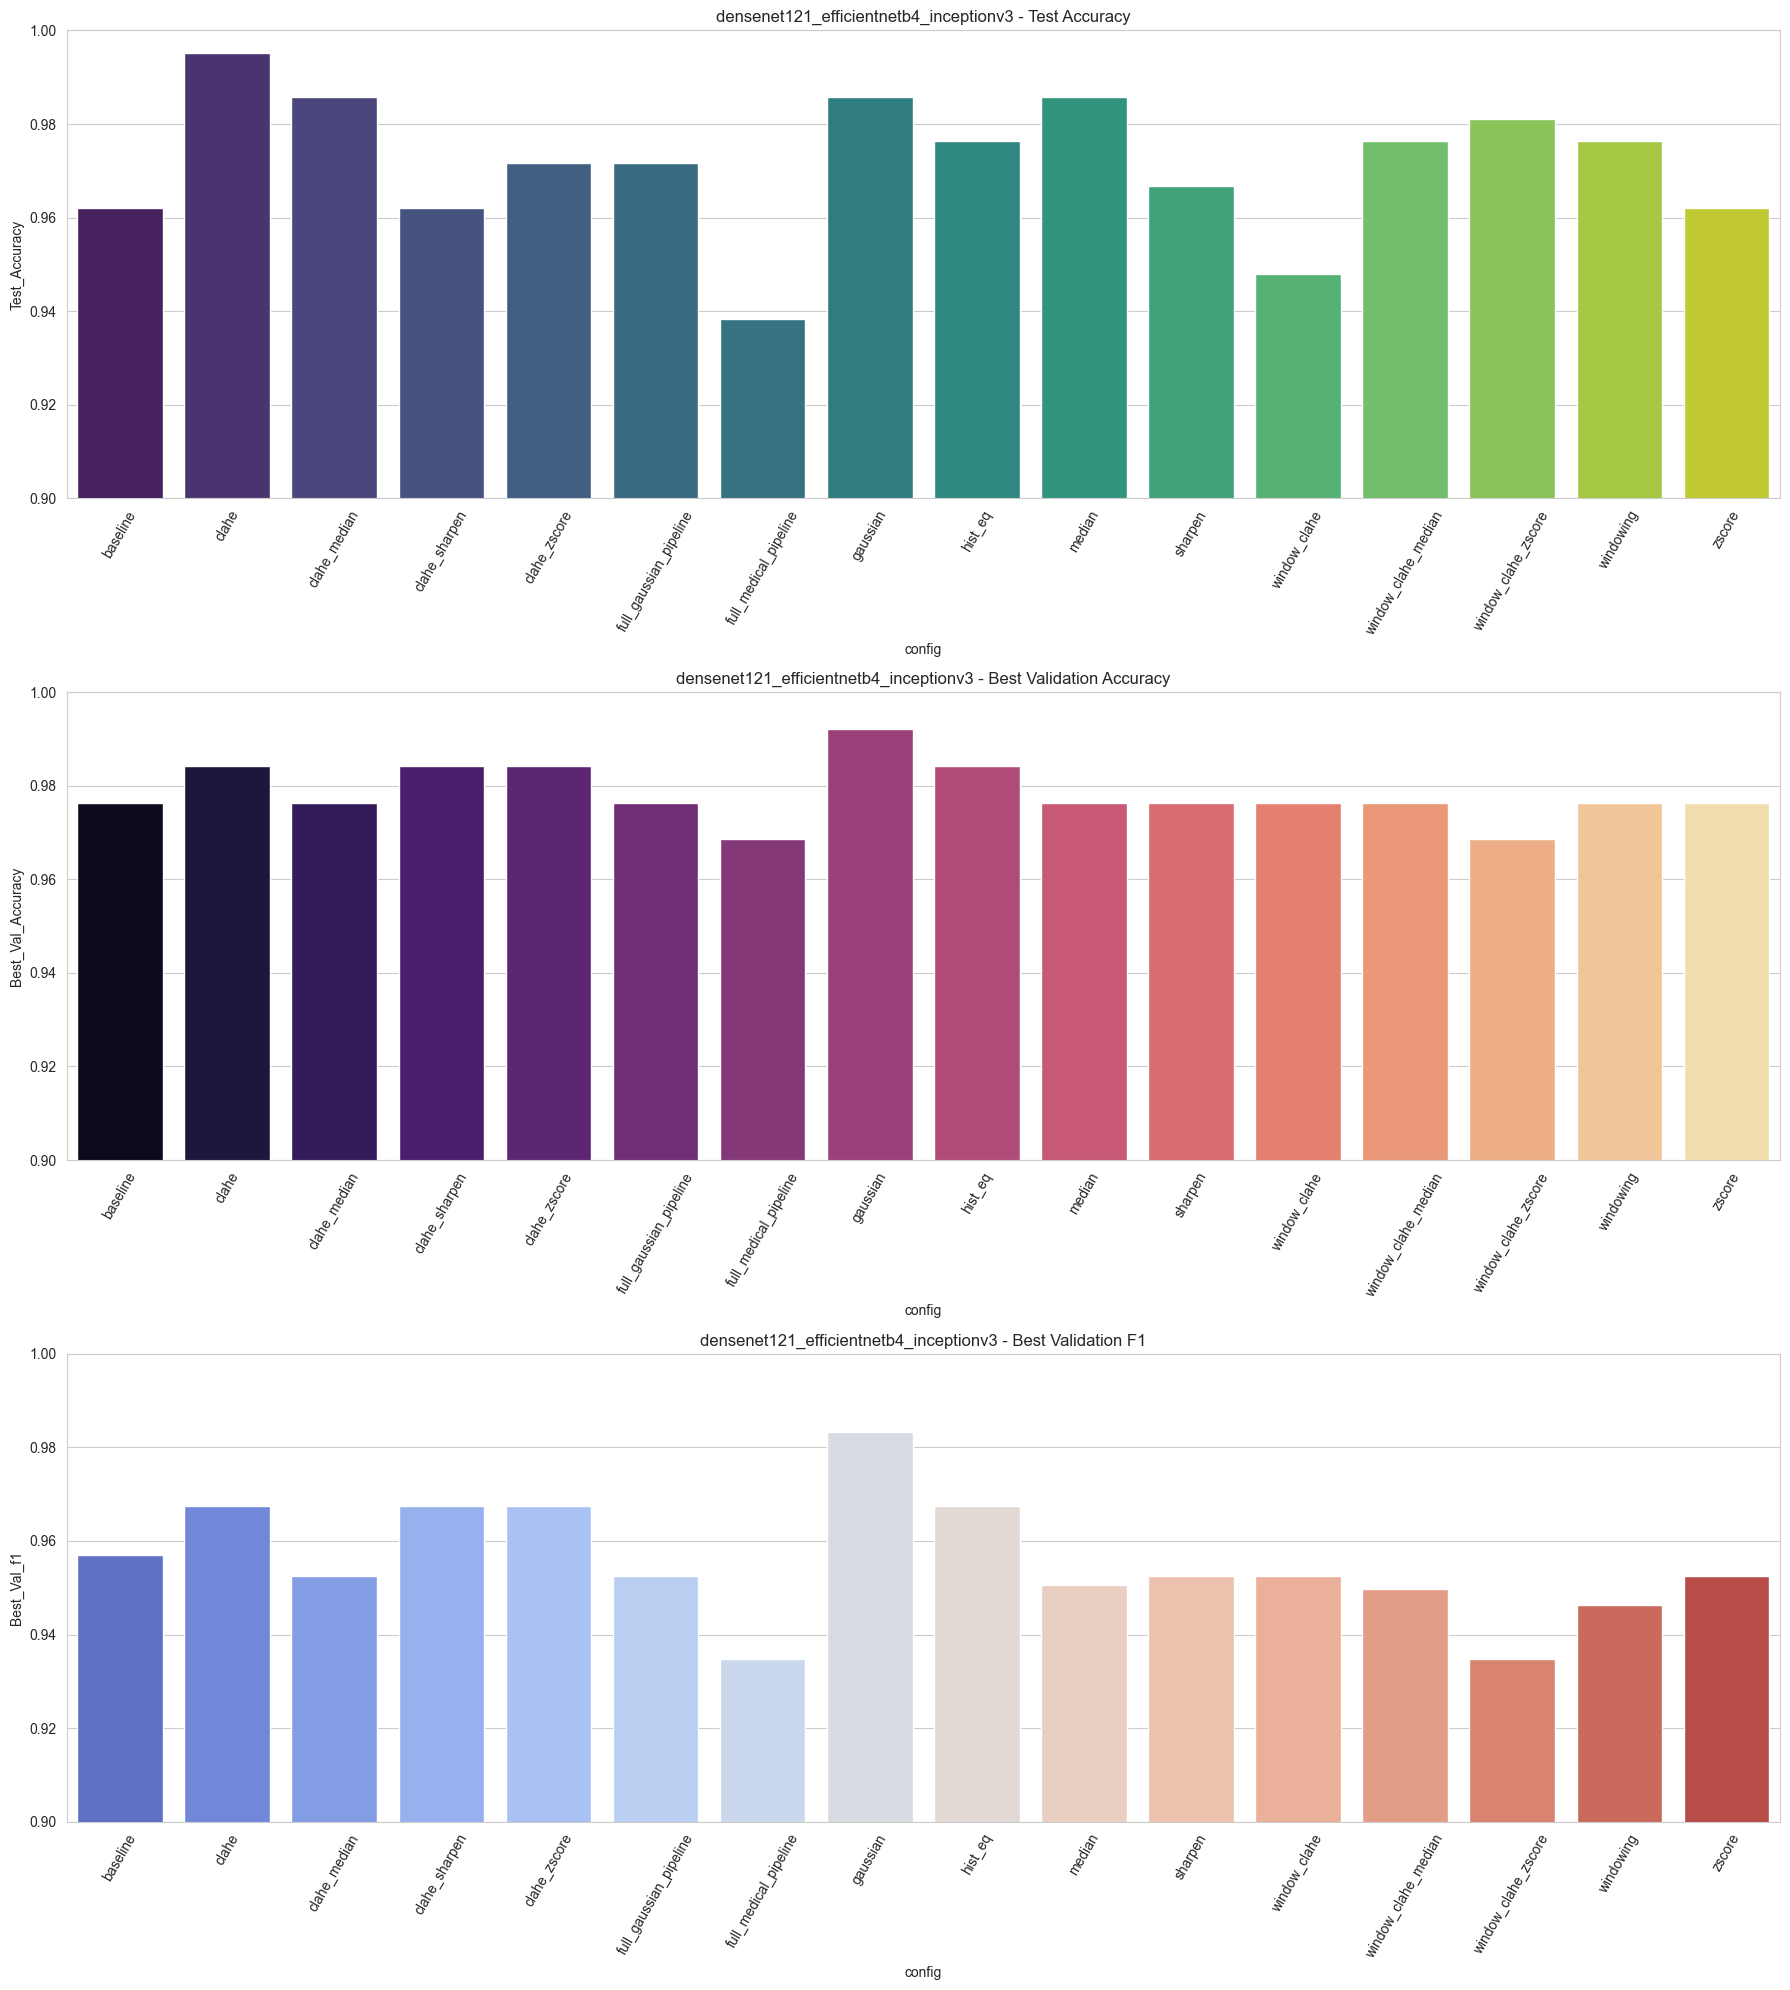

C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_7176\1080074645.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


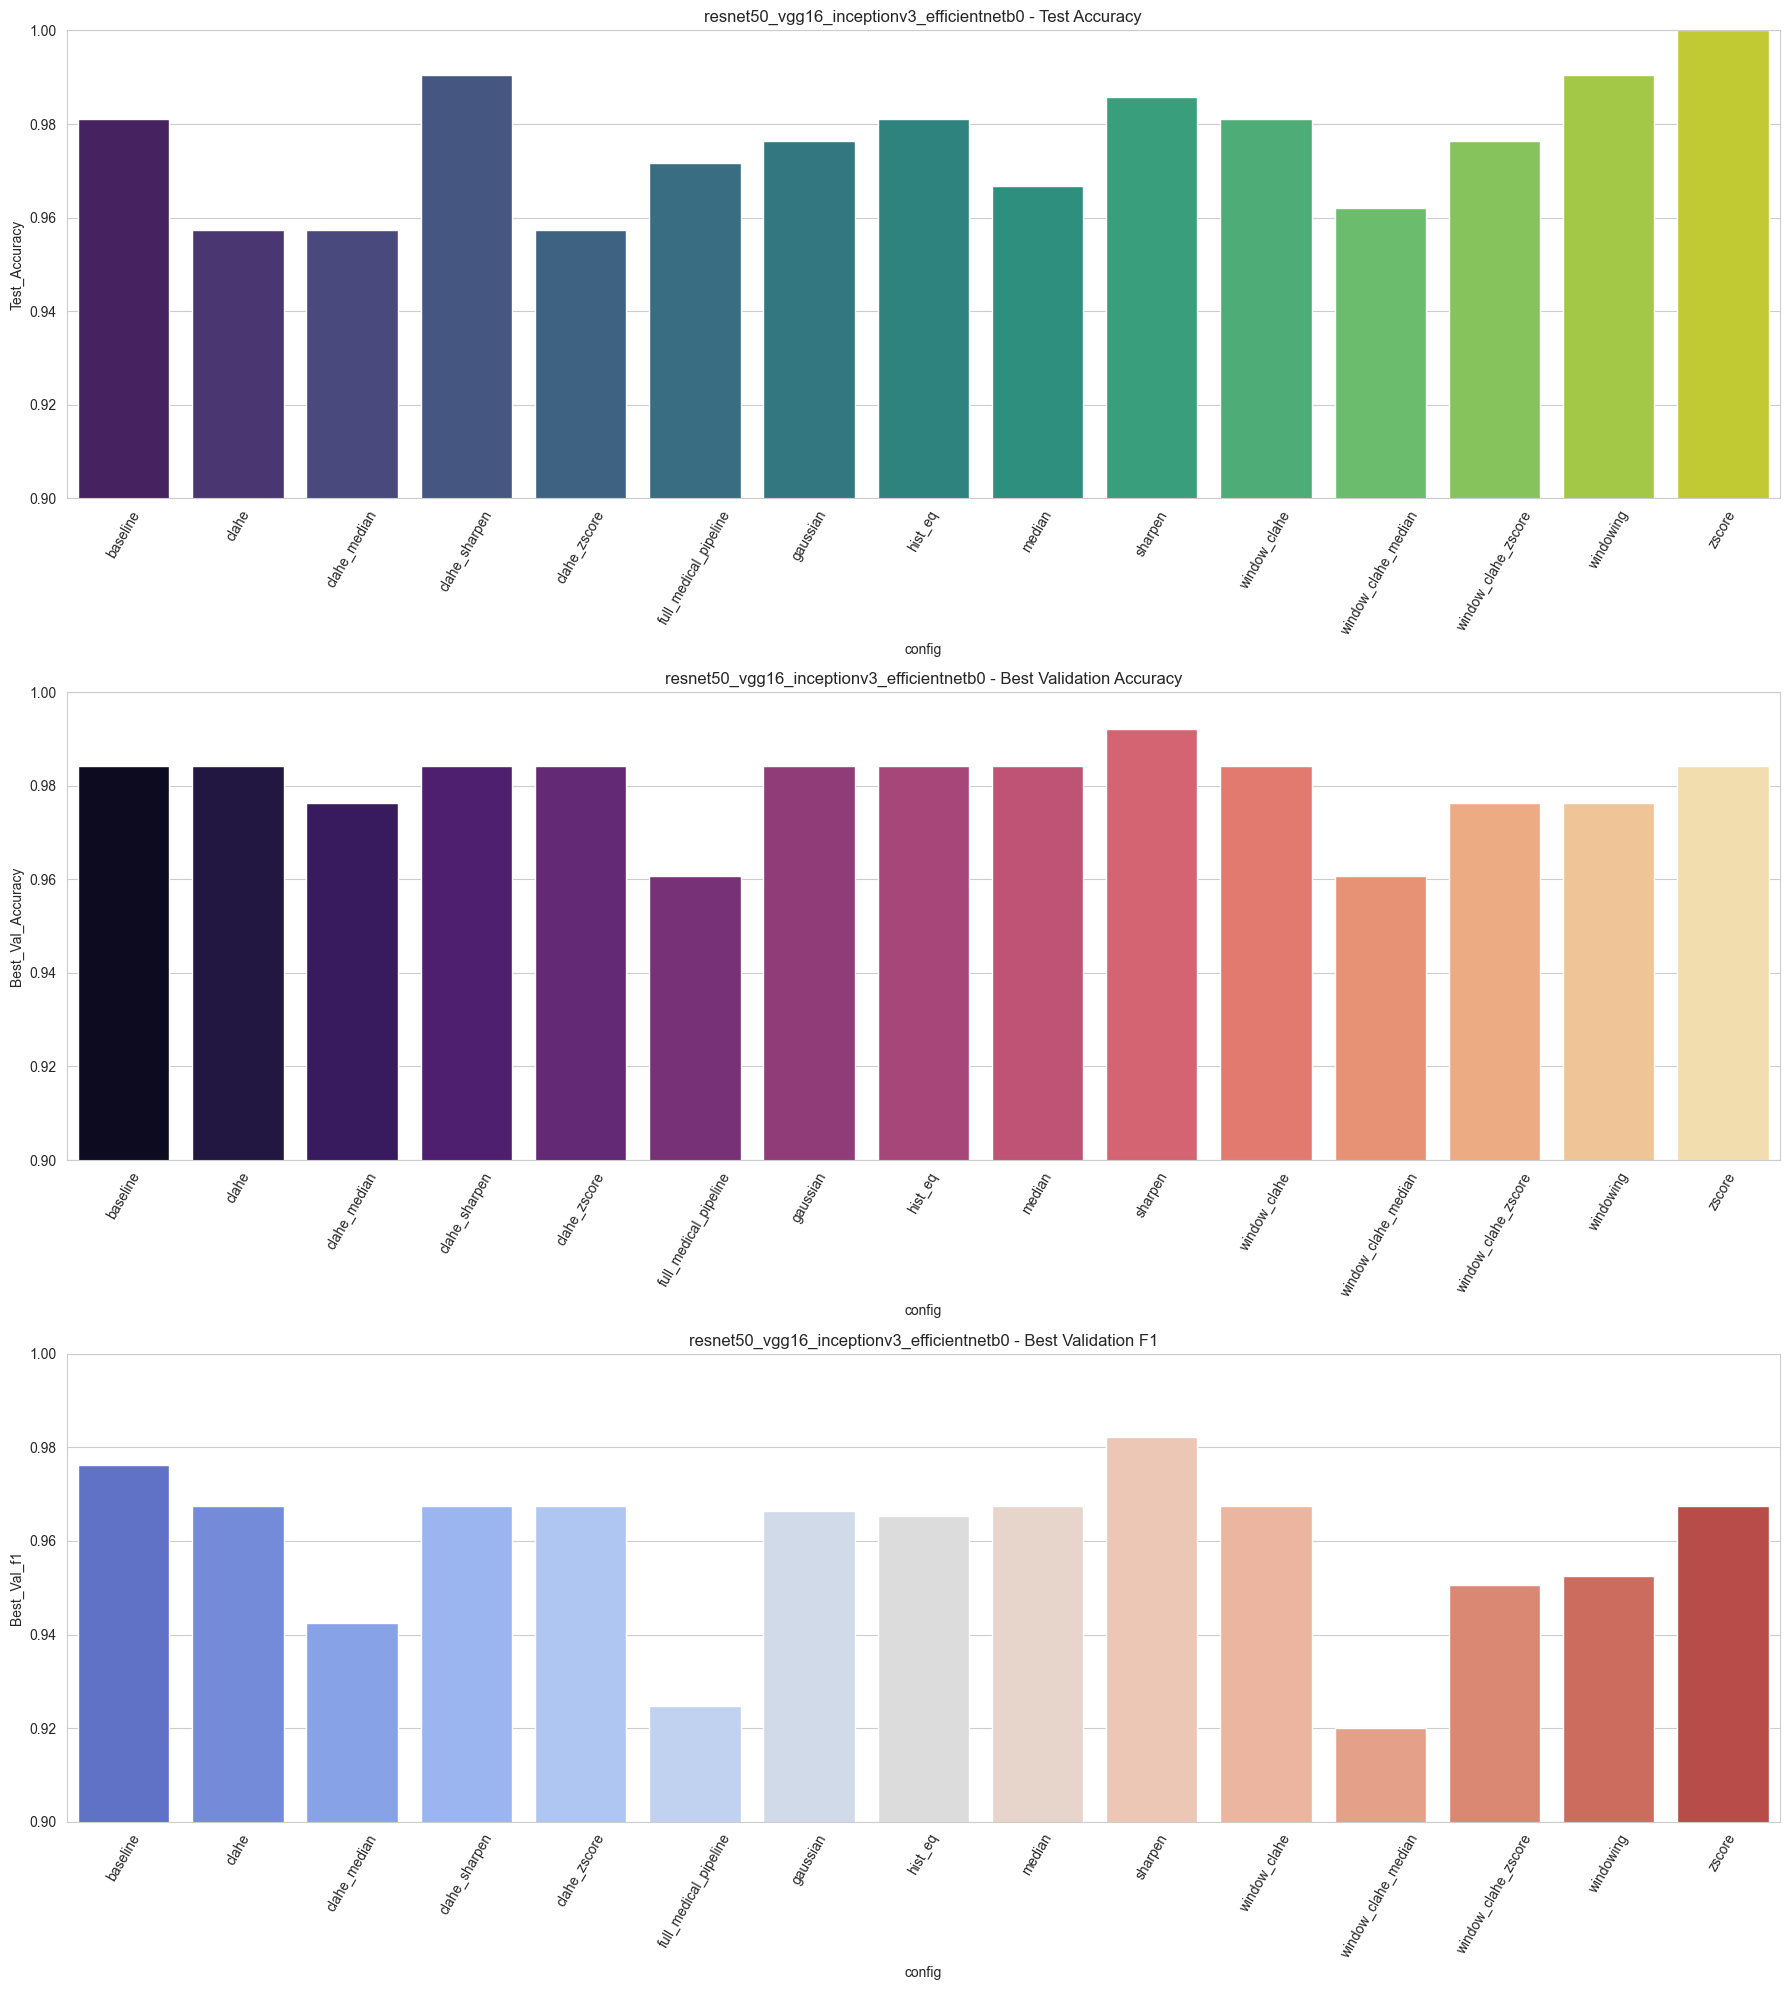

Charts generated successfully!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("results/charts-seaborn/hybrid", exist_ok=True)

sns.set_style("whitegrid")

models = df["hybrid_model"].unique()

range = 0.9

for model in models:

    model_df = df[df["hybrid_model"] == model]
    model_df = model_df.sort_values("config")

    fig, axes = plt.subplots(3, 1, figsize=(18, 20))

    # -------- Test Accuracy --------
    sns.barplot(
        data=model_df,
        x="config",
        y="Test_Accuracy",
        ax=axes[0],
        palette="viridis"
    )

    axes[0].set_title(f"{model} - Test Accuracy")
    axes[0].set_ylim(range, 1)
    axes[0].tick_params(axis='x', rotation=60)

    # -------- Validation Accuracy --------
    sns.barplot(
        data=model_df,
        x="config",
        y="Best_Val_Accuracy",
        ax=axes[1],
        palette="magma"
    )

    axes[1].set_title(f"{model} - Best Validation Accuracy")
    axes[1].set_ylim(range, 1)
    axes[1].tick_params(axis='x', rotation=60)

    # -------- Validation F1 --------
    sns.barplot(
        data=model_df,
        x="config",
        y="Best_Val_f1",
        ax=axes[2],
        palette="coolwarm"
    )

    axes[2].set_title(f"{model} - Best Validation F1")
    axes[2].set_ylim(range, 1)
    axes[2].tick_params(axis='x', rotation=60)

    plt.tight_layout()
    plt.savefig(f"results/charts-seaborn/hybrid/{model}_performance.png")
    plt.show()
    plt.close()

print("Charts generated successfully!")